In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pandas.api.types import CategoricalDtype
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [35]:
df1 = pd.read_csv('df_final_web_data_clean')
df2 = pd.read_csv('df_final_experiment_clients_cleaned')
df3 = pd.read_csv('df_final_demo_cleaned')
merged_df = pd.merge(df1, df2, on="client_id", how="inner")

# Then merge the result with df3
merged_df = pd.merge(merged_df, df3, on="client_id", how="inner")

In [36]:
merged_df

,Unnamed: 0_x,client_id,visitor_id,visit_id,process_step,date_time,Unnamed: 0_y,variation,Unnamed: 0.1,Unnamed: 0,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,6,4726500,934350987_45569789638,467318052_88159801968_565608,confirm,2017-06-05 17:38:52,34,Test,33273,16006,14,178,46.0,F,2,43357.46,6,9
1,7,4726500,934350987_45569789638,467318052_88159801968_565608,step_3,2017-06-05 17:38:33,34,Test,33273,16006,14,178,46.0,F,2,43357.46,6,9
2,8,4726500,934350987_45569789638,467318052_88159801968_565608,step_2,2017-06-05 17:37:31,34,Test,33273,16006,14,178,46.0,F,2,43357.46,6,9
3,9,4726500,934350987_45569789638,467318052_88159801968_565608,step_1,2017-06-05 17:37:24,34,Test,33273,16006,14,178,46.0,F,2,43357.46,6,9
4,10,4726500,934350987_45569789638,467318052_88159801968_565608,start,2017-06-05 17:37:16,34,Test,33273,16006,14,178,46.0,F,2,43357.46,6,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321202,657575,5305116,87196875_82592805389,69164930_20082199445_40666,confirm,2017-04-20 09:30:11,50494,Control,37376,34713,18,226,63.5,F,3,89726.65,2,5
321203,657576,5305116,87196875_82592805389,69164930_20082199445_40666,step_3,2017-04-20 09:27:44,50494,Control,37376,34713,18,226,63.5,F,3,89726.65,2,5
321204,657577,5305116,87196875_82592805389,69164930_20082199445_40666,step_2,2017-04-20 09:26:41,50494,Control,37376,34713,18,226,63.5,F,3,89726.65,2,5
321205,657578,5305116,87196875_82592805389,69164930_20082199445_40666,step_1,2017-04-20 09:25:58,50494,Control,37376,34713,18,226,63.5,F,3,89726.65,2,5


In [37]:
merged_df = merged_df.drop(columns=['Unnamed: 0_x','Unnamed: 0_y','Unnamed: 0.1','Unnamed: 0'])


In [38]:
df = merged_df


In [39]:
balance_threshold = df["bal"].quantile(0.90)    

df["primary_client"] = (
    (df["bal"] >= balance_threshold)
)

In [61]:
df

,client_id,visitor_id,visit_id,process_step,date_time,variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,...,timestamp,time_diff,next_start,time_spent,prev_step,is_error,prev_time,from_step,to_step,next_time
150815,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test,3,46,29.5,U,...,2017-04-15 12:57:56,NaT,2017-04-15 12:58:03,0.116667,NaN,False,NaT,NaN,start,2017-04-15 12:58:03
150814,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test,3,46,29.5,U,...,2017-04-15 12:58:03,0 days 00:00:07,2017-04-15 12:58:35,0.533333,start,False,2017-04-15 12:57:56,start,step_1,2017-04-15 12:58:35
150813,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test,3,46,29.5,U,...,2017-04-15 12:58:35,0 days 00:00:32,2017-04-15 13:00:14,1.650000,step_1,False,2017-04-15 12:58:03,step_1,step_2,2017-04-15 13:00:14
150812,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test,3,46,29.5,U,...,2017-04-15 13:00:14,0 days 00:01:39,2017-04-15 13:00:34,0.333333,step_2,False,2017-04-15 12:58:35,step_2,step_3,2017-04-15 13:00:34
150811,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test,3,46,29.5,U,...,2017-04-15 13:00:34,0 days 00:00:20,NaT,NaN,step_3,False,2017-04-15 13:00:14,step_3,confirm,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34917,9999729,834634258_21862004160,870243567_56915814033_814203,step_2,2017-05-08 16:08:40,Test,10,124,31.0,F,...,2017-05-08 16:08:40,0 days 00:00:10,2017-05-08 16:09:19,0.650000,step_1,False,2017-05-08 16:08:30,step_1,step_2,2017-05-08 16:09:19
34916,9999729,834634258_21862004160,870243567_56915814033_814203,step_3,2017-05-08 16:09:19,Test,10,124,31.0,F,...,2017-05-08 16:09:19,0 days 00:00:39,2017-05-08 16:09:40,0.350000,step_2,False,2017-05-08 16:08:40,step_2,step_3,2017-05-08 16:09:40
34915,9999729,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,Test,10,124,31.0,F,...,2017-05-08 16:09:40,0 days 00:00:21,NaT,NaN,step_3,False,2017-05-08 16:09:19,step_3,confirm,NaT
3747,9999832,145538019_54444341400,472154369_16714624241_585315,start,2017-05-16 16:46:03,Test,23,281,49.0,F,...,2017-05-16 16:46:03,NaT,2017-05-16 16:46:11,0.133333,NaN,False,NaT,NaN,start,2017-05-16 16:46:11


In [41]:
df.process_step.unique()

array(['confirm', 'step_3', 'step_2', 'step_1', 'start'], dtype=object)

In [42]:
(df['variation'] == 'Test').value_counts()

variation
True     177787
False    143420
Name: count, dtype: int64

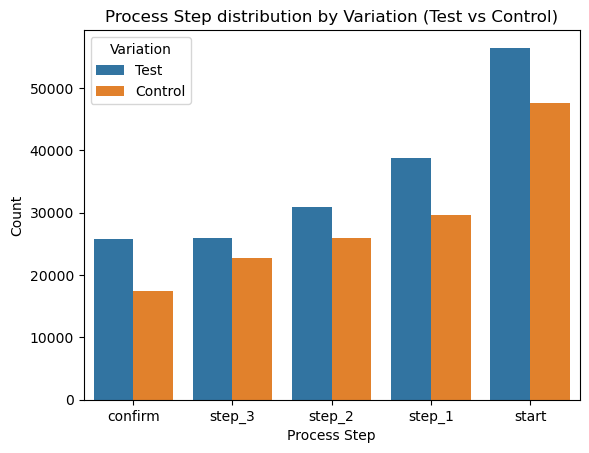

In [43]:
sns.countplot(data=df, x="process_step", hue="variation")
plt.title("Process Step distribution by Variation (Test vs Control)")
plt.xlabel("Process Step")
plt.ylabel("Count")
plt.legend(title="Variation")
plt.show()

  variation process_step  count  percentage
0   Control      confirm  17499   12.201227
1   Control        start  47594   33.185051
2   Control       step_1  29659   20.679822
3   Control       step_2  25879   18.044206
4   Control       step_3  22789   15.889695
5      Test      confirm  25716   14.464500
6      Test        start  56452   31.752603
7      Test       step_1  38753   21.797432
8      Test       step_2  30978   17.424221
9      Test       step_3  25888   14.561245


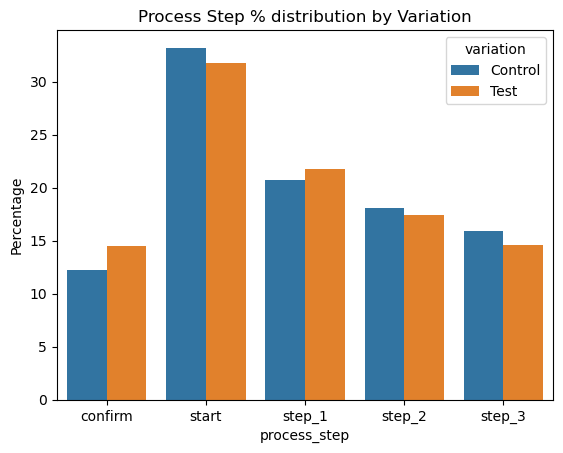

In [44]:
step_var = (df
            .groupby(["variation", "process_step"])
            .size()
            .reset_index(name="count"))

# Convert to percentages within each variation
step_var["percentage"] = step_var.groupby("variation")["count"].transform(lambda x: x / x.sum() * 100)

print(step_var)

# Plot as bar chart
sns.barplot(data=step_var, x="process_step", y="percentage", hue="variation")
plt.title("Process Step % distribution by Variation")
plt.ylabel("Percentage")
plt.show()

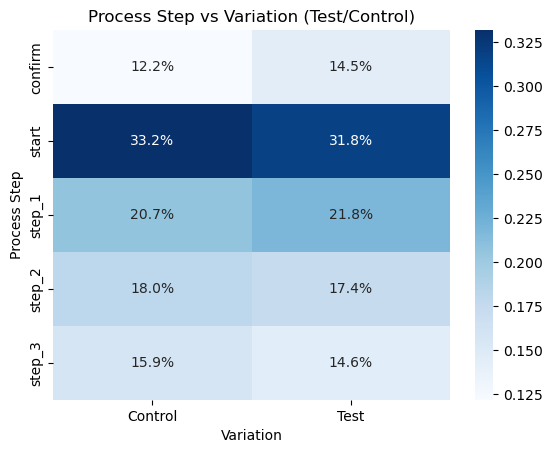

In [45]:
pivot = pd.crosstab(df["process_step"], df["variation"], normalize="columns")

sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".1%")
plt.title("Process Step vs Variation (Test/Control)")
plt.xlabel("Variation")
plt.ylabel("Process Step")
plt.show()

In [46]:
rate = (df[df['process_step'] == 'confirm']
    .groupby('variation')['client_id']
    .nunique())
rate

variation
Control    15429
Test       18682
Name: client_id, dtype: int64

In [47]:
completion_rate = (
    df[df['process_step'] == 'confirm']
    .groupby('variation')['client_id']
    .nunique()
    / df.groupby('variation')['client_id'].nunique()
) * 100

print(completion_rate)


variation
Control    65.579972
Test       69.292682
Name: client_id, dtype: float64


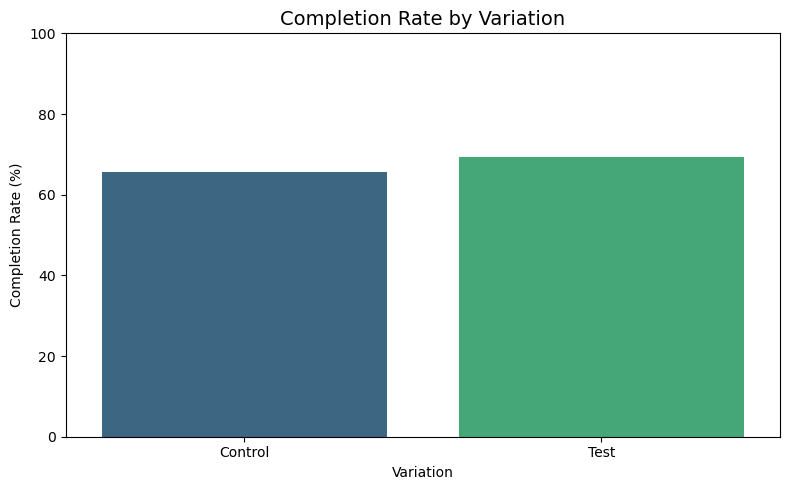

In [48]:
# Calculate completion rate per variation
completion_rate = (
    df[df['process_step'] == 'confirm']
    .groupby('variation')['client_id']
    .nunique()
    / df.groupby('variation')['client_id'].nunique()
) * 100

# Prepare DataFrame for Seaborn
completion_df = completion_rate.reset_index()
completion_df.columns = ['variation', 'completion_rate']

# Plot bar chart with hue assigned properly
plt.figure(figsize=(8, 5))
sns.barplot(
    data=completion_df,
    x="variation",
    y="completion_rate",
    hue="variation",   # ✅ fixed
    palette="viridis",
    legend=False
)
plt.title("Completion Rate by Variation", fontsize=14)
plt.ylabel("Completion Rate (%)")
plt.xlabel("Variation")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


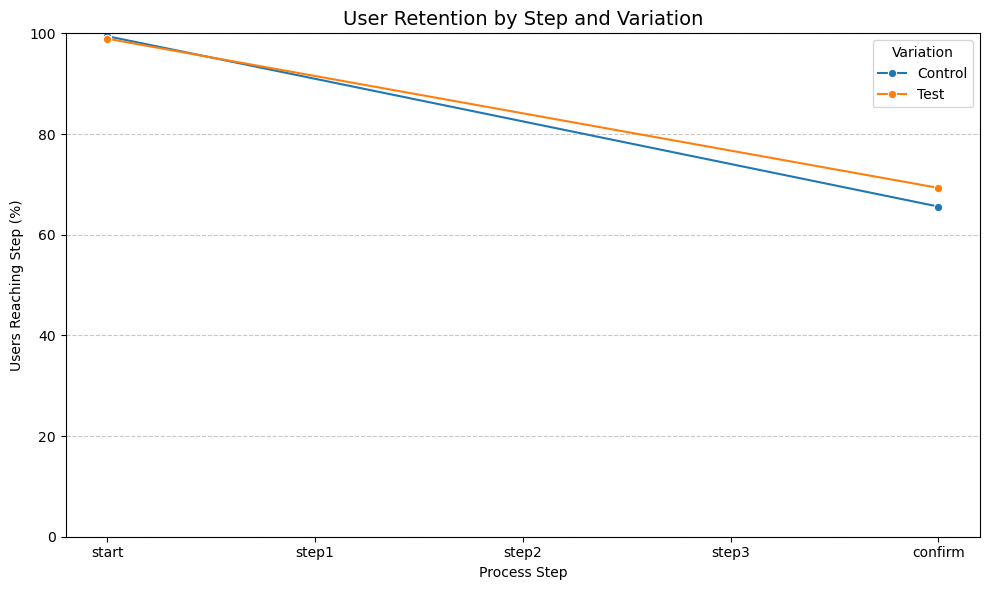

In [49]:
# Total users per variation
total_users = df.groupby('variation')['client_id'].nunique()

# Users per step per variation
users_per_step = df.groupby(['variation', 'process_step'])['client_id'].nunique().reset_index()

# Calculate percentage of users reaching each step
users_per_step['percentage'] = users_per_step.apply(
    lambda x: (x['client_id'] / total_users.loc[x['variation']]) * 100, axis=1
)

# Sort process steps if needed
step_order = ['start', 'step1', 'step2', 'step3', 'confirm']  # <-- adjust based on your dataset
users_per_step['process_step'] = pd.Categorical(users_per_step['process_step'], categories=step_order, ordered=True)
users_per_step = users_per_step.sort_values(['variation', 'process_step'])

# Plot funnel chart
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=users_per_step,
    x='process_step',
    y='percentage',
    hue='variation',  # ✅ fixed
    marker="o"
)
plt.title("User Retention by Step and Variation", fontsize=14)
plt.ylabel("Users Reaching Step (%)")
plt.xlabel("Process Step")
plt.ylim(0, 100)
plt.legend(title="Variation")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


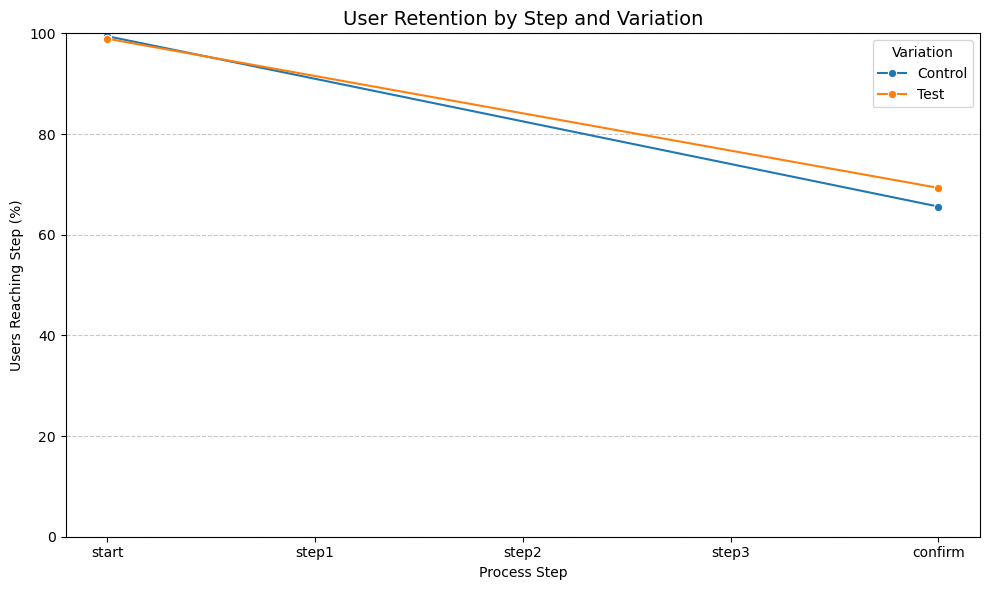

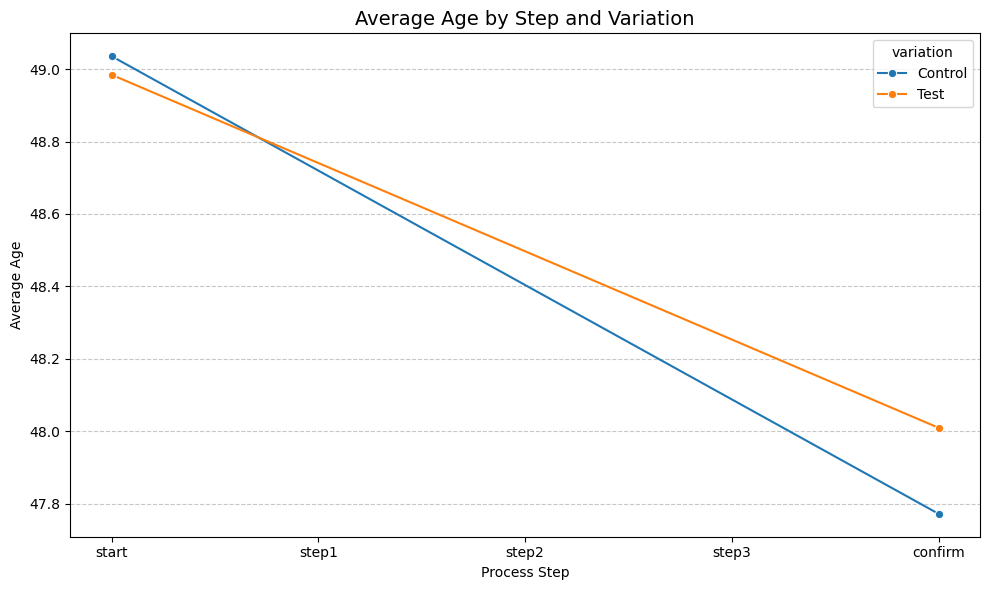

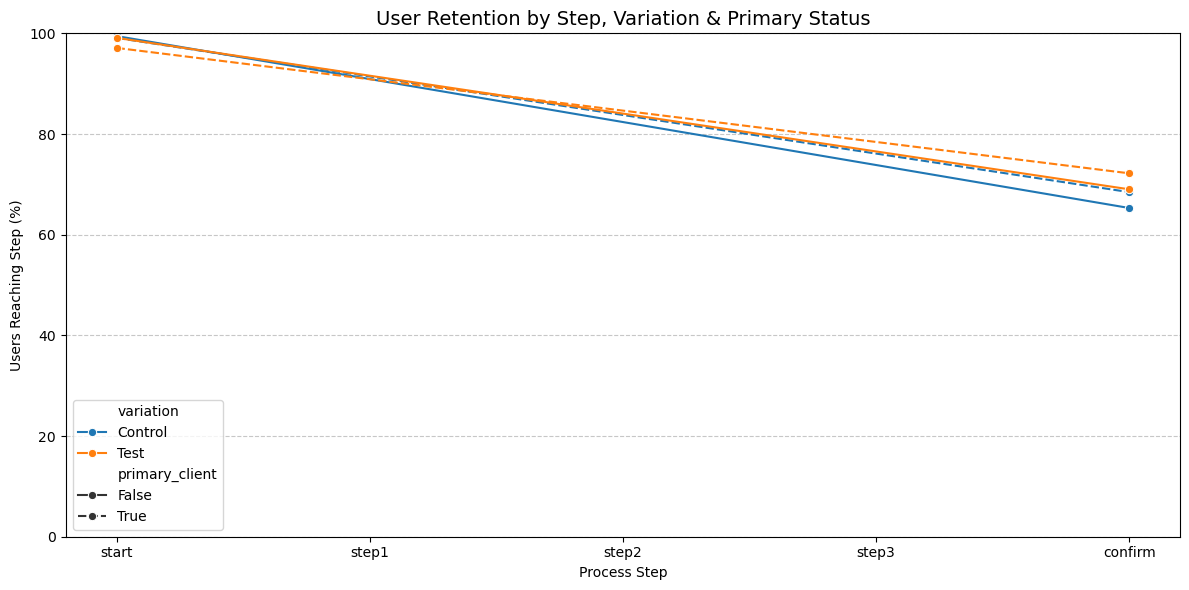

In [50]:
total_users = df.groupby('variation')['client_id'].nunique()

# -------------------
# 2) Users per step per variation
# -------------------
users_per_step = (
    df.groupby(['variation', 'process_step'])['client_id']
    .nunique()
    .reset_index()
)

# Percentage reaching each step
users_per_step['percentage'] = users_per_step.apply(
    lambda x: (x['client_id'] / total_users.loc[x['variation']]) * 100,
    axis=1
)

# -------------------
# 3) Sort process steps
# -------------------
step_order = ['start', 'step1', 'step2', 'step3', 'confirm']
users_per_step['process_step'] = pd.Categorical(
    users_per_step['process_step'],
    categories=step_order,
    ordered=True
)
users_per_step = users_per_step.sort_values(['variation', 'process_step'])

# -------------------
# 4) Funnel chart (original)
# -------------------
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=users_per_step,
    x='process_step',
    y='percentage',
    hue='variation',
    marker="o"
)
plt.title("User Retention by Step and Variation", fontsize=14)
plt.ylabel("Users Reaching Step (%)")
plt.xlabel("Process Step")
plt.ylim(0, 100)
plt.legend(title="Variation")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# -------------------
# 5) NEW → Average age per step & variation
# -------------------
avg_age_step = (
    df.groupby(['variation', 'process_step'])['clnt_age']
    .mean()
    .reset_index()
)
avg_age_step['process_step'] = pd.Categorical(
    avg_age_step['process_step'],
    categories=step_order,
    ordered=True
)
avg_age_step = avg_age_step.sort_values(['variation', 'process_step'])

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=avg_age_step,
    x='process_step',
    y='clnt_age',
    hue='variation',
    marker="o"
)
plt.title("Average Age by Step and Variation", fontsize=14)
plt.ylabel("Average Age")
plt.xlabel("Process Step")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# -------------------
# 6) NEW → Split funnel by primary vs non-primary client
# -------------------
# Count unique users by variation, step, and primary_client
users_primary = (
    df.groupby(['variation', 'process_step', 'primary_client'])['client_id']
    .nunique()
    .reset_index()
)

# Calculate percentages within each variation + primary status
total_per_group = df.groupby(['variation', 'primary_client'])['client_id'].nunique()
users_primary['percentage'] = users_primary.apply(
    lambda x: (x['client_id'] / total_per_group.loc[(x['variation'], x['primary_client'])]) * 100,
    axis=1
)

users_primary['process_step'] = pd.Categorical(
    users_primary['process_step'],
    categories=step_order,
    ordered=True
)
users_primary = users_primary.sort_values(['variation', 'primary_client', 'process_step'])

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=users_primary,
    x='process_step',
    y='percentage',
    hue='variation',
    style='primary_client',  # separate line styles for primary vs non-primary
    marker="o"
)
plt.title("User Retention by Step, Variation & Primary Status", fontsize=14)
plt.ylabel("Users Reaching Step (%)")
plt.xlabel("Process Step")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

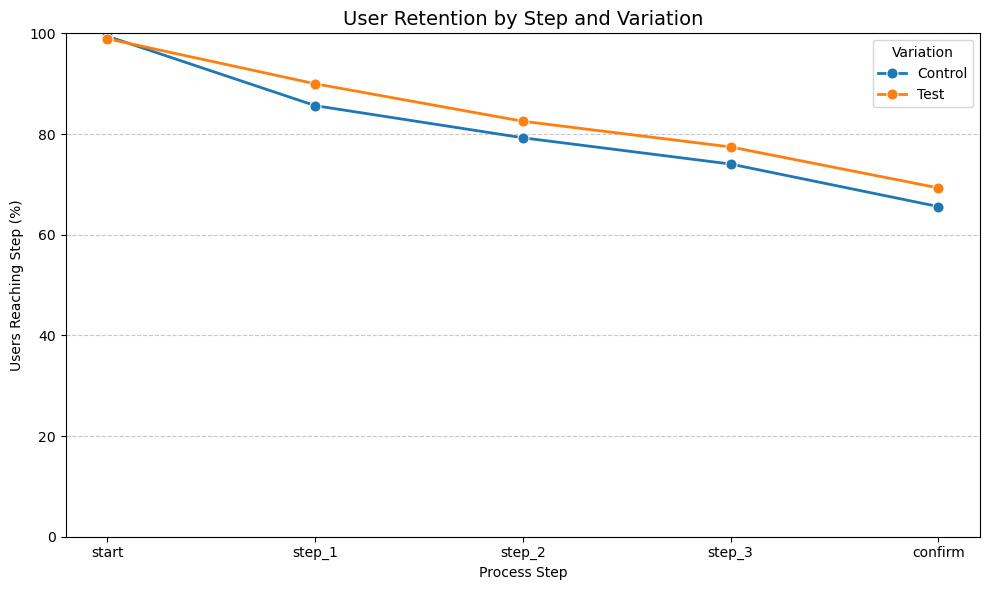

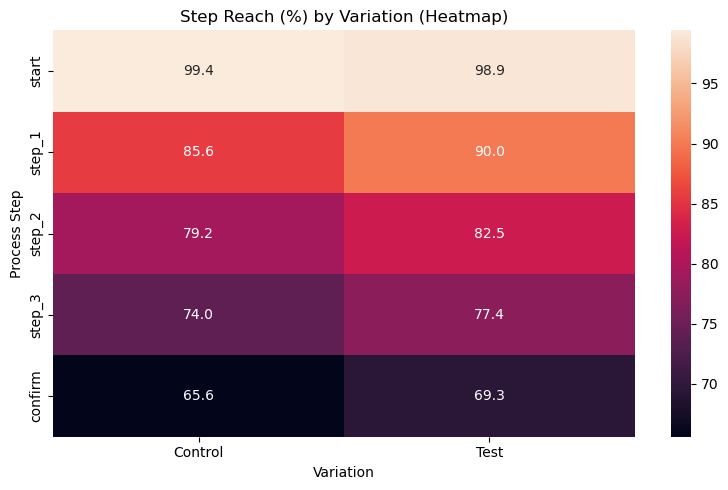

In [51]:

# CONFIG (your step labels)
# =========================
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
step_to_pos = {s: i for i, s in enumerate(step_order)}

# =========================
# CLEANUP / TYPES
# =========================
df = df.copy()

# Ensure 'process_step' uses your exact labels and is categorical (ordered)
df['process_step'] = (
    df['process_step']
      .astype('string')
      .str.strip()
)
# Optional: warn if unexpected labels exist
unexpected = set(df['process_step'].dropna().unique()) - set(step_order)
if unexpected:
    print("⚠️ Unexpected step labels found (not in step_order):", unexpected)

df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)

# Ensure 'variation' is categorical (use new deprecation-safe check)
from pandas.api.types import CategoricalDtype
if not isinstance(df['variation'].dtype, CategoricalDtype):
    df['variation'] = df['variation'].astype('category')
variations = list(df['variation'].cat.categories)

# =========================
# 1) USERS PER STEP & PERCENTAGES
# =========================
# Total unique users per variation
total_users = (
    df.groupby('variation', observed=True)['client_id']
      .nunique()
      .reindex(variations, fill_value=0)
)

# Unique users per (variation, step)
users_per_step = (
    df.groupby(['variation', 'process_step'], observed=True)['client_id']
      .nunique()
      .rename('users')
      .reset_index()
)

# Ensure all (variation x step) combos exist
mi = pd.MultiIndex.from_product([variations, step_order], names=['variation', 'process_step'])
users_per_step = (
    users_per_step.set_index(['variation', 'process_step'])
                  .reindex(mi, fill_value=0)
                  .reset_index()
)

# Percent reaching each step within each variation
users_per_step['percentage'] = (
    users_per_step['users'] /
    users_per_step['variation'].map(total_users).replace(0, np.nan) * 100
).fillna(0)

# Add numeric x position to HARD-LOCK the order
users_per_step['step_pos'] = users_per_step['process_step'].map(step_to_pos)

# =========================
# 2) FUNNEL CHART (with dots, fixed order)
# =========================
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=users_per_step.sort_values(['variation','step_pos']),
    x='step_pos', y='percentage',
    hue='variation',
    marker='o', dashes=False, linewidth=2, markersize=8,
    ax=ax
)
ax.set_title("User Retention by Step and Variation", fontsize=14)
ax.set_ylabel("Users Reaching Step (%)")
ax.set_xlabel("Process Step")
ax.set_ylim(0, 100)
ax.set_xticks(range(len(step_order)))
ax.set_xticklabels(step_order)
ax.grid(axis='y', linestyle="--", alpha=0.7)
ax.legend(title="Variation")
plt.tight_layout()
plt.show()
# =========================
# 4) HEATMAP (% reach per step & variation)
# =========================
pivot_pct = (
    users_per_step.pivot(index='process_step', columns='variation', values='percentage')
    .reindex(index=step_order, columns=variations)
)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_pct, annot=True, fmt=".1f")
plt.title("Step Reach (%) by Variation (Heatmap)")
plt.ylabel("Process Step")
plt.xlabel("Variation")
plt.tight_layout()
plt.show()



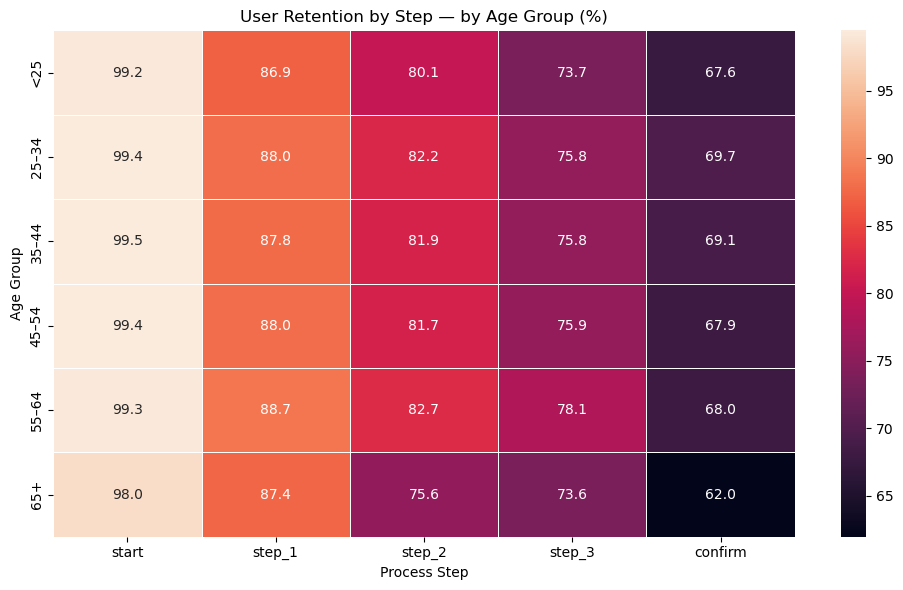

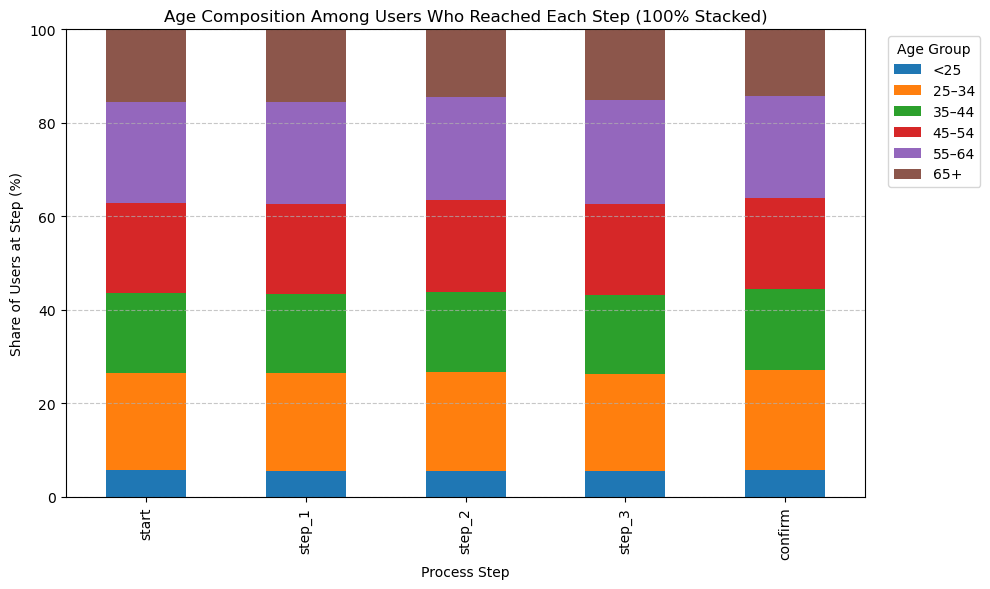

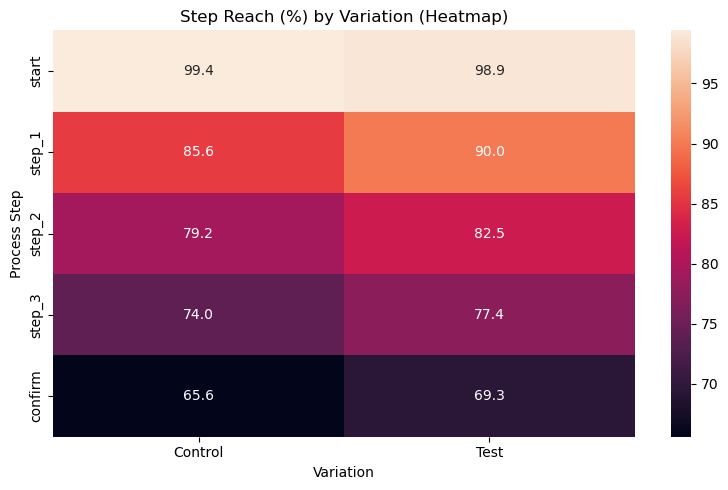

In [52]:
step_order  = ['start', 'step_1', 'step_2', 'step_3', 'confirm']  # adjust if needed
age_bins    = [0, 24, 34, 44, 54, 64, 120]
age_labels  = ['<25', '25–34', '35–44', '45–54', '55–64', '65+']

df = df.copy()

# Steps as ordered categorical (and warn if unexpected labels show up)
df['process_step'] = df['process_step'].astype('string').str.strip()
unexpected = set(df['process_step'].dropna().unique()) - set(step_order)
if unexpected:
    print("⚠️ Unexpected step labels (not in step_order):", unexpected)
df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)

# Age groups
df = df[df['clnt_age'].notna()].copy()
df['age_group'] = pd.cut(df['clnt_age'], bins=age_bins, labels=age_labels, include_lowest=True, right=True)

# ------------------
# A) HEATMAP — Retention by age group (rows) and step (cols)
#    (% of unique users in each age group who reached the step)
# ------------------
# Denominator per age group
den_age = (
    df.groupby('age_group', observed=True)['client_id']
      .nunique()
      .rename('denom')
      .reset_index()
)

# Numerator per (age_group, step)
num_age_step = (
    df.groupby(['age_group','process_step'], observed=True)['client_id']
      .nunique()
      .rename('users')
      .reset_index()
)

# Retention %
age_ret = num_age_step.merge(den_age, on='age_group', how='left')
age_ret['percentage'] = (age_ret['users'] / age_ret['denom'].replace(0, np.nan) * 100).fillna(0)

# Pivot for heatmap
heat = (
    age_ret
    .pivot(index='age_group', columns='process_step', values='percentage')
    .reindex(index=age_labels, columns=step_order)
)

plt.figure(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt=".1f", linewidths=.5)
plt.title("User Retention by Step — by Age Group (%)")
plt.xlabel("Process Step")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

# ------------------
# B) 100% STACKED BAR — Age mix among users who reached each step
#    (for each step, bars sum to 100% across age groups)
# ------------------
# Numerator per (step, age_group)
num_step_age = (
    df.groupby(['process_step','age_group'], observed=True)['client_id']
      .nunique()
      .rename('users')
      .reset_index()
)

# Denominator per step (all users who reached the step)
den_step = (
    df.groupby('process_step', observed=True)['client_id']
      .nunique()
      .rename('denom')
      .reset_index()
)

mix = num_step_age.merge(den_step, on='process_step', how='left')
mix['pct_of_step'] = (mix['users'] / mix['denom'].replace(0, np.nan) * 100).fillna(0)

mix_pivot = (
    mix.pivot(index='process_step', columns='age_group', values='pct_of_step')
       .reindex(index=step_order, columns=age_labels)
       .fillna(0)
)

# 100% stacked bars
ax = mix_pivot.plot(kind='bar', stacked=True, figsize=(10, 6))
ax.set_title("Age Composition Among Users Who Reached Each Step (100% Stacked)")
ax.set_xlabel("Process Step")
ax.set_ylabel("Share of Users at Step (%)")
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
# =========================
# 4) HEATMAP (% reach per step & variation)
# =========================
pivot_pct = (
    users_per_step.pivot(index='process_step', columns='variation', values='percentage')
    .reindex(index=step_order, columns=variations)
)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_pct, annot=True, fmt=".1f")
plt.title("Step Reach (%) by Variation (Heatmap)")
plt.ylabel("Process Step")
plt.xlabel("Variation")
plt.tight_layout()
plt.show()


In [53]:
df['timestamp'] = pd.to_datetime(df['date_time'])
df = df.sort_values(['client_id', 'timestamp'])

df['time_diff'] = df.groupby('client_id')['timestamp'].diff()

avg_time_per_step = df.groupby(['variation', 'process_step'])['time_diff'].mean()
print(avg_time_per_step)


variation  process_step
Control    start          4 days 06:00:00.843642966
           step_1         0 days 00:30:39.337504650
           step_2         0 days 00:00:39.347493332
           step_3         0 days 00:09:35.350907253
           confirm        0 days 18:21:25.156749327
Test       start          3 days 02:55:37.780723214
           step_1         0 days 00:22:20.321410097
           step_2         0 days 00:01:51.238731757
           step_3         0 days 00:12:19.069989559
           confirm        1 days 05:00:41.146959592
Name: time_diff, dtype: timedelta64[ns]


C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\4201142583.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_time_per_step = df.groupby(['variation', 'process_step'])['time_diff'].mean()


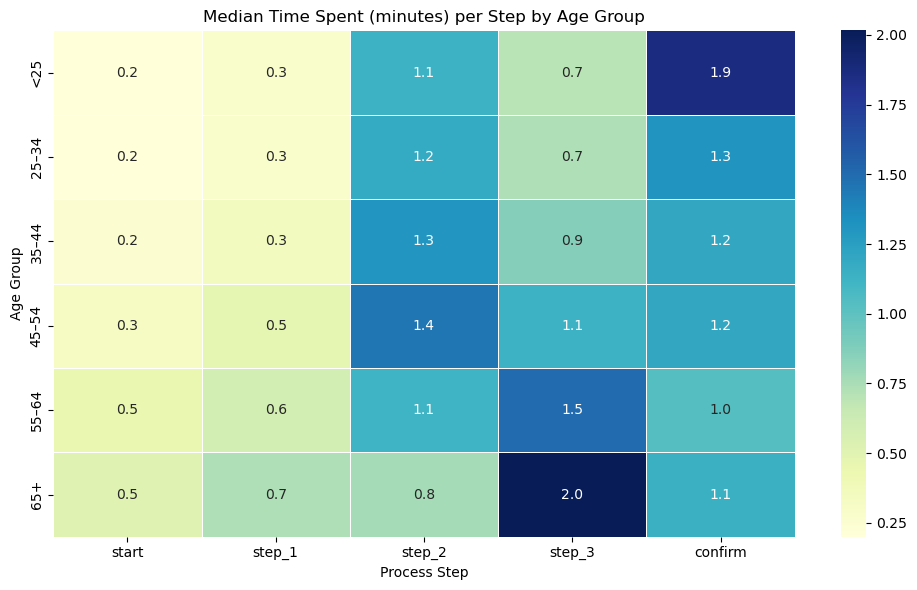

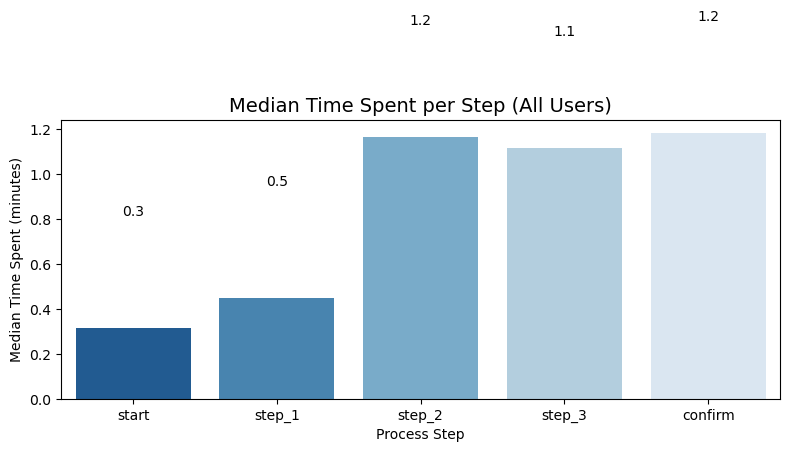

In [54]:
# ---------------------
# CONFIG
# ---------------------
step_order  = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
age_bins    = [0, 24, 34, 44, 54, 64, 120]
age_labels  = ['<25', '25–34', '35–44', '45–54', '55–64', '65+']

# ---------------------
# CLEAN DATA
# ---------------------
df = df.copy()
df['date_time'] = pd.to_datetime(df['date_time'])
df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)
df = df[df['clnt_age'].notna()].copy()
df['age_group'] = pd.cut(df['clnt_age'], bins=age_bins, labels=age_labels, include_lowest=True)

# ---------------------
# 1) COMPUTE TIME SPENT IN EACH STEP
# ---------------------
df = df.sort_values(['client_id', 'process_step', 'date_time'])
df['next_start'] = df.groupby('client_id')['date_time'].shift(-1)
df['time_spent'] = (df['next_start'] - df['date_time']).dt.total_seconds() / 60

# Drop last-step rows where next_start is NaN
df_time = df.dropna(subset=['time_spent']).copy()

# ---------------------
# 2) REMOVE OUTLIERS
# ---------------------
# Keep times <= 120 minutes (2 hours)
df_time = df_time[df_time['time_spent'] <= 120]

# ---------------------
# 3) MEDIAN TIME PER STEP BY AGE (HEATMAP)
# ---------------------
median_time_age = (
    df_time.groupby(['age_group', 'process_step'], observed=True)['time_spent']
           .median()
           .reset_index()
)

heat = median_time_age.pivot(index='age_group', columns='process_step', values='time_spent')
heat = heat.reindex(index=age_labels, columns=step_order)

plt.figure(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title("Median Time Spent (minutes) per Step by Age Group")
plt.xlabel("Process Step")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

# ---------------------
# 4) MEDIAN TIME PER STEP (OVERALL)
# ---------------------
# Compute median time per step
median_time_step = (
    df_time.groupby('process_step', observed=True)['time_spent']
           .median()
           .reindex(step_order)       # ✅ ensures all steps appear
           .fillna(0)                 # ✅ fill missing steps with 0
           .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=median_time_step,
    x='process_step',
    y='time_spent',
    hue='process_step',   # ✅ fix palette warning
    palette="Blues_r",
    legend=False,
    order=step_order
)
plt.title("Median Time Spent per Step (All Users)", fontsize=14)
plt.xlabel("Process Step")
plt.ylabel("Median Time Spent (minutes)")

# Add labels on bars
for i, v in enumerate(median_time_step['time_spent']):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [55]:
# Si un usuario regresa a un paso anterior, lo contamos como error
df['prev_step'] = df.groupby('client_id')['process_step'].shift()
df['is_error'] = df['process_step'] < df['prev_step']

error_rate = df.groupby(['variation', 'process_step'])['is_error'].mean() * 100
print(error_rate)


variation  process_step
Control    start           0.0
           step_1          0.0
           step_2          0.0
           step_3          0.0
           confirm         0.0
Test       start           0.0
           step_1          0.0
           step_2          0.0
           step_3          0.0
           confirm         0.0
Name: is_error, dtype: float64


C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\2975432537.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_rate = df.groupby(['variation', 'process_step'])['is_error'].mean() * 100


Total transitions: 222,858
Total error transitions (backward moves): 32,213  → Overall error rate: 14.45%
Users with ≥1 error: 40.89%

Error rate by FROM step:
  from_step  total  errors  error_rate_pct
0     start  60593       0        0.000000
1    step_1  61507   11135       18.103630
2    step_2  53930    8036       14.900797
3    step_3  44304   10518       23.740520
4   confirm   2524    2524      100.000000

Error rate by TO step:
   to_step  total  errors  error_rate_pct
0    start  21778   21778      100.000000
1   step_1  65200    5787        8.875767
2   step_2  55221    4642        8.406222
3   step_3  46483       6        0.012908
4  confirm  34176       0        0.000000

Error rate by Variation x FROM step:
  variation from_step  total  errors  error_rate_pct
0   Control     start  26263       0        0.000000
1   Control    step_1  26109    3551       13.600674
2   Control    step_2  24193    2747       11.354524
3   Control    step_3  20437    5102       24.964525
4  

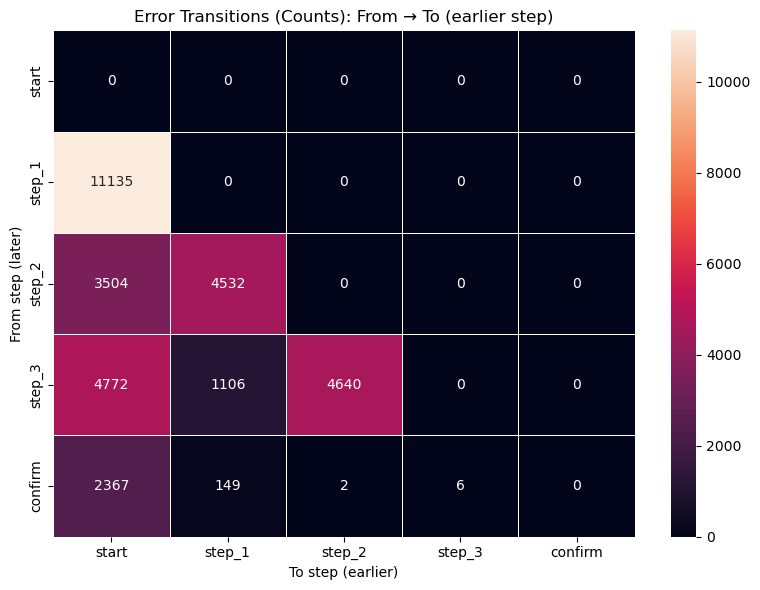

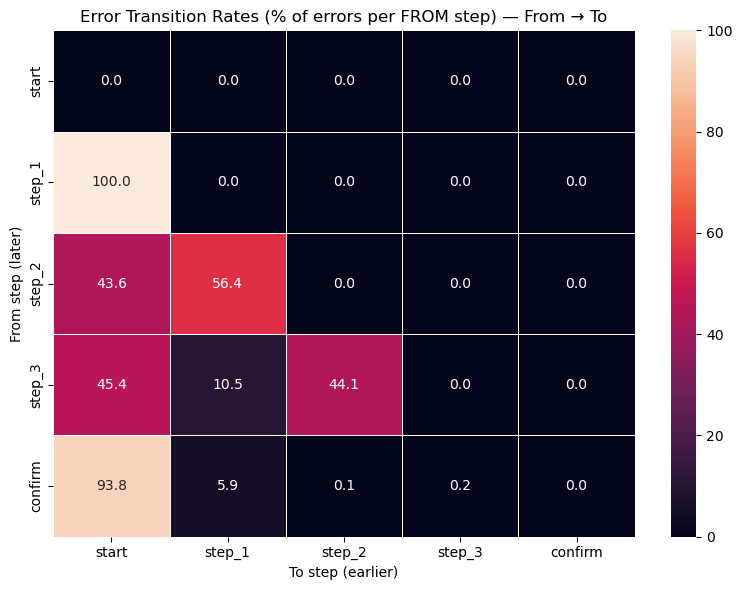

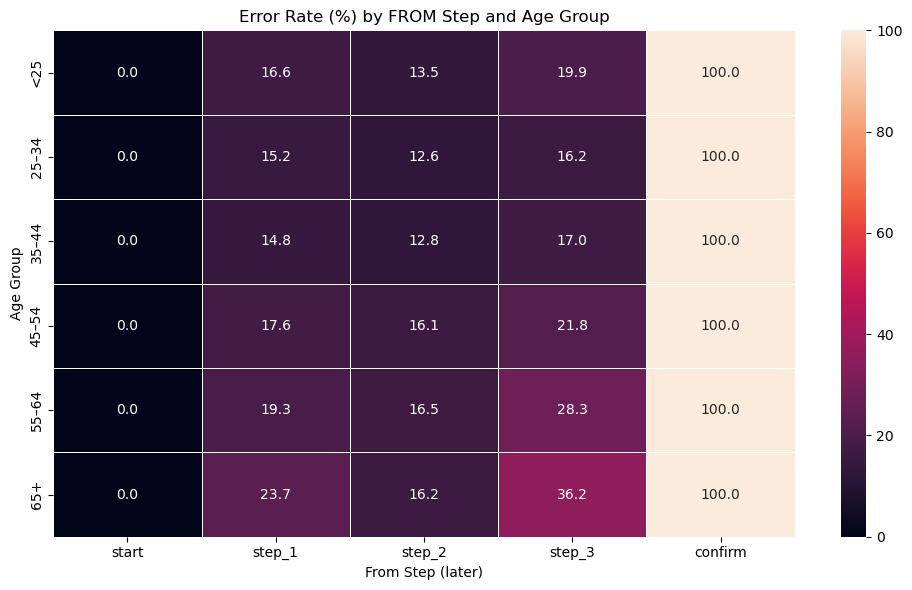

In [56]:
# ---------------------
# CONFIG
# ---------------------
step_order  = ['start', 'step_1', 'step_2', 'step_3', 'confirm']  # <- your labels
age_bins    = [0, 24, 34, 44, 54, 64, 120]
age_labels  = ['<25', '25–34', '35–44', '45–54', '55–64', '65+']

df = df.copy()

# Ensure datetime and ordered categories
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')
df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)

# (Optional) Age groups if you want age-based error rates later
if 'clnt_age' in df.columns:
    df = df[df['clnt_age'].notna()].copy()
    df['age_group'] = pd.cut(df['clnt_age'], bins=age_bins, labels=age_labels, include_lowest=True)

# If variation exists, make it categorical for stable ordering
if 'variation' in df.columns and not isinstance(df['variation'].dtype, pd.CategoricalDtype):
    from pandas.api.types import CategoricalDtype
    df['variation'] = df['variation'].astype('category')

# ---------------------
# 1) BUILD TRANSITIONS PER USER (ordered by time)
# ---------------------
# Sort strictly by client and time
df = df.sort_values(['client_id', 'date_time'])

# Previous row (the "from" state) within each client
df['prev_step'] = df.groupby('client_id', observed=True)['process_step'].shift(1)
df['prev_time'] = df.groupby('client_id', observed=True)['date_time'].shift(1)
df['from_step'] = df['prev_step']
df['to_step']   = df['process_step']

# Keep only actual transitions (i.e., rows that have a previous step)
transitions = df.loc[df['from_step'].notna(), ['client_id','variation','age_group','from_step','to_step','prev_time','date_time']].copy()

# Remove no-op transitions (same step repeated); we only care about moves between different steps
transitions = transitions.loc[transitions['from_step'] != transitions['to_step']].copy()

# Rank steps to detect backward moves
rank = {s:i for i, s in enumerate(step_order)}
transitions['from_rank'] = transitions['from_step'].map(rank)
transitions['to_rank']   = transitions['to_step'].map(rank)

# Error = move to an earlier rank (backwards in the funnel)
transitions['is_error'] = transitions['to_rank'] < transitions['from_rank']

# For reference: transition duration (mins) between steps (not used for error flag)
transitions['delta_minutes'] = (transitions['date_time'] - transitions['prev_time']).dt.total_seconds() / 60

# ---------------------
# 2) ERROR RATE METRICS
# ---------------------
total_transitions = len(transitions)
total_errors = int(transitions['is_error'].sum())
error_rate_overall = (total_errors / total_transitions * 100) if total_transitions > 0 else 0.0

# Error rate by "from" step (how often leaving a given step results in an error)
err_by_from = (
    transitions.groupby('from_step', observed=True)['is_error']
               .agg(total='count', errors='sum')
               .assign(error_rate_pct=lambda d: np.where(d['total']>0, d['errors']/d['total']*100, 0.0))
               .reindex(step_order)
               .fillna({'total':0, 'errors':0, 'error_rate_pct':0.0})
               .reset_index()
)

# Error rate by "to" step (how often arrivals to a step are errors)
err_by_to = (
    transitions.groupby('to_step', observed=True)['is_error']
               .agg(total='count', errors='sum')
               .assign(error_rate_pct=lambda d: np.where(d['total']>0, d['errors']/d['total']*100, 0.0))
               .reindex(step_order)
               .fillna({'total':0, 'errors':0, 'error_rate_pct':0.0})
               .reset_index()
)

# Error rate by variation & from_step (if variation exists)
if 'variation' in transitions.columns:
    err_by_var_from = (
        transitions.groupby(['variation','from_step'], observed=True)['is_error']
                   .agg(total='count', errors='sum')
                   .assign(error_rate_pct=lambda d: np.where(d['total']>0, d['errors']/d['total']*100, 0.0))
                   .reset_index()
    )
else:
    err_by_var_from = pd.DataFrame()

# % of users with at least one error (user-level KPI)
err_by_user = (
    transitions.groupby('client_id', observed=True)['is_error']
               .any()
               .rename('had_error')
               .reset_index()
)
pct_users_with_error = (err_by_user['had_error'].mean() * 100) if len(err_by_user) else 0.0

print(f"Total transitions: {total_transitions:,}")
print(f"Total error transitions (backward moves): {total_errors:,}  → Overall error rate: {error_rate_overall:.2f}%")
print(f"Users with ≥1 error: {pct_users_with_error:.2f}%")

print("\nError rate by FROM step:")
print(err_by_from)

print("\nError rate by TO step:")
print(err_by_to)

if not err_by_var_from.empty:
    print("\nError rate by Variation x FROM step:")
    print(err_by_var_from)

# ---------------------
# 3) VISUALS — ERROR TRANSITION MATRIX (from → to)
# ---------------------
# A) Count of error transitions
err_matrix_counts = (
    transitions.loc[transitions['is_error']]
               .groupby(['from_step','to_step'], observed=True)
               .size()
               .unstack('to_step')
               .reindex(index=step_order, columns=step_order)
               .fillna(0)
)

plt.figure(figsize=(8, 6))
sns.heatmap(err_matrix_counts, annot=True, fmt=".0f", linewidths=.5)
plt.title("Error Transitions (Counts): From → To (earlier step)")
plt.xlabel("To step (earlier)")
plt.ylabel("From step (later)")
plt.tight_layout()
plt.show()

# B) Error rate per FROM step across TO steps (row-normalized)
row_totals = err_matrix_counts.sum(axis=1).replace(0, np.nan)
err_matrix_rates = (err_matrix_counts.div(row_totals, axis=0) * 100).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(err_matrix_rates, annot=True, fmt=".1f", linewidths=.5)
plt.title("Error Transition Rates (% of errors per FROM step) — From → To")
plt.xlabel("To step (earlier)")
plt.ylabel("From step (later)")
plt.tight_layout()
plt.show()

# ---------------------
# 4) (OPTIONAL) ERROR RATE BY AGE GROUP
# ---------------------
if 'age_group' in transitions.columns:
    err_by_age_from = (
        transitions.groupby(['age_group','from_step'], observed=True)['is_error']
                   .agg(total='count', errors='sum')
                   .assign(error_rate_pct=lambda d: np.where(d['total']>0, d['errors']/d['total']*100, 0.0))
                   .reset_index()
    )
    # Force display order
    err_by_age_from['from_step'] = pd.Categorical(err_by_age_from['from_step'], categories=step_order, ordered=True)
    err_by_age_from['age_group'] = pd.Categorical(err_by_age_from['age_group'], categories=age_labels, ordered=True)
    err_by_age_from = err_by_age_from.sort_values(['age_group','from_step'])

    # Heatmap: age (rows) x step (cols) with error_rate_pct
    heat_age = (
        err_by_age_from.pivot(index='age_group', columns='from_step', values='error_rate_pct')
                       .reindex(index=age_labels, columns=step_order)
                       .fillna(0)
    )
    plt.figure(figsize=(10, 6))
    sns.heatmap(heat_age, annot=True, fmt=".1f", linewidths=.5)
    plt.title("Error Rate (%) by FROM Step and Age Group")
    plt.xlabel("From Step (later)")
    plt.ylabel("Age Group")
    plt.tight_layout()
    plt.show()

C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\4268691512.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_var = transitions.groupby('variation', observed=True).apply(summarize_errors).reset_index()


=== Error Summary (Overall) ===
   total_transitions  error_transitions  error_rate_pct  backward_errors  \
0           270719.0            80074.0           29.58          32213.0   

   repeat_errors  backward_share_pct  repeat_share_pct  
0        47861.0               40.23             59.77  

=== Error Summary by Variation ===
  variation  total_transitions  error_transitions  error_rate_pct  \
0   Control           119893.0            34291.0           28.60   
1      Test           150826.0            45783.0           30.35   

   backward_errors  repeat_errors  backward_share_pct  repeat_share_pct  
0          13201.0        21090.0               38.50             61.50  
1          19012.0        26771.0               41.53             58.47  

=== Error Rate by FROM Step (Overall) ===
  from_step  total  errors  error_rate_pct
0     start  92887   32294           34.77
1    step_1  64538   14166           21.95
2    step_2  55552    9658           17.39
3    step_3  46443  

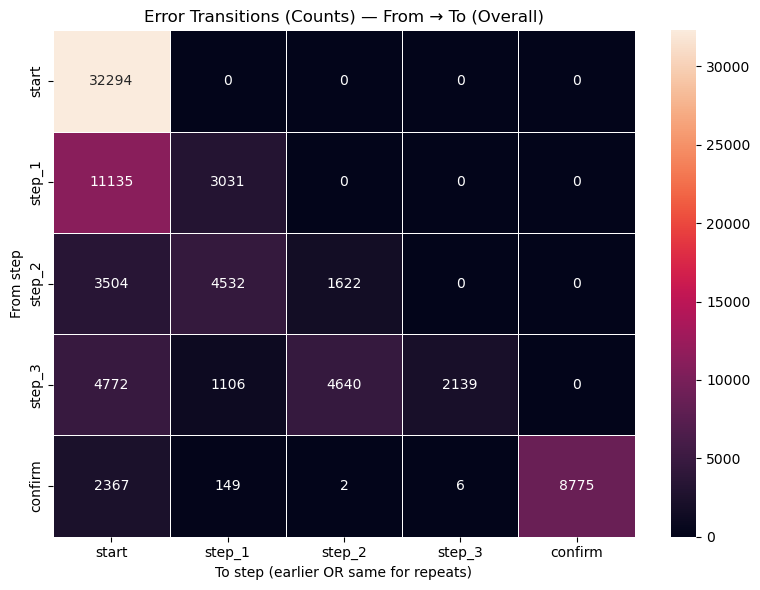

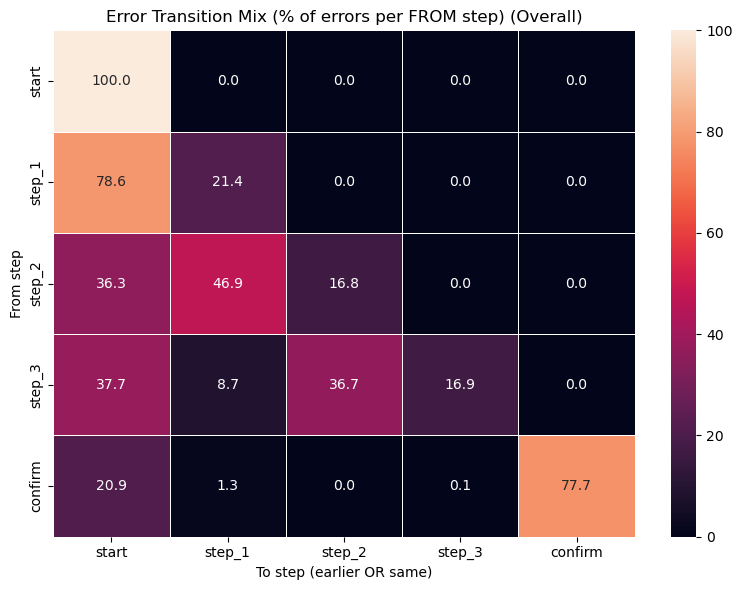

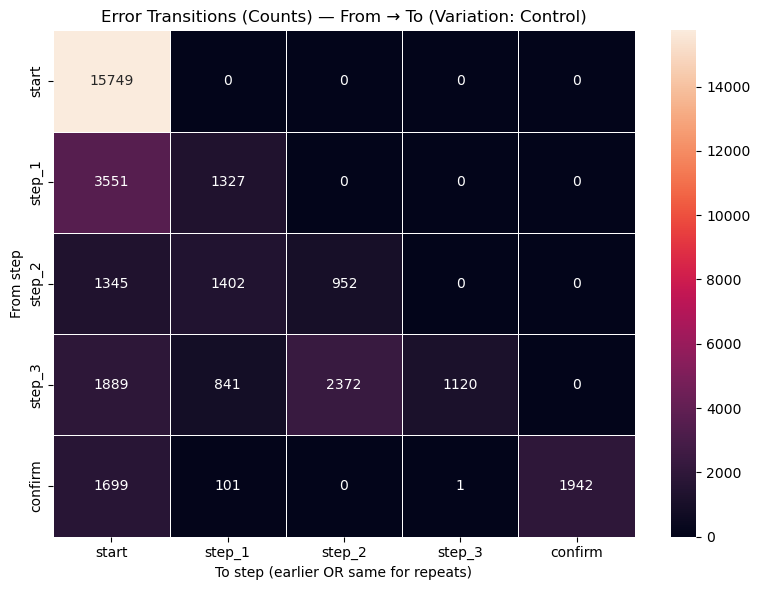

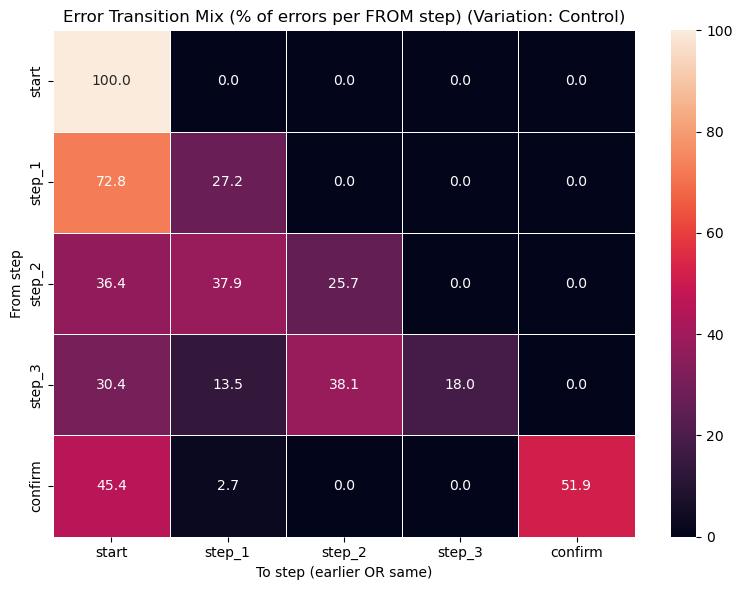

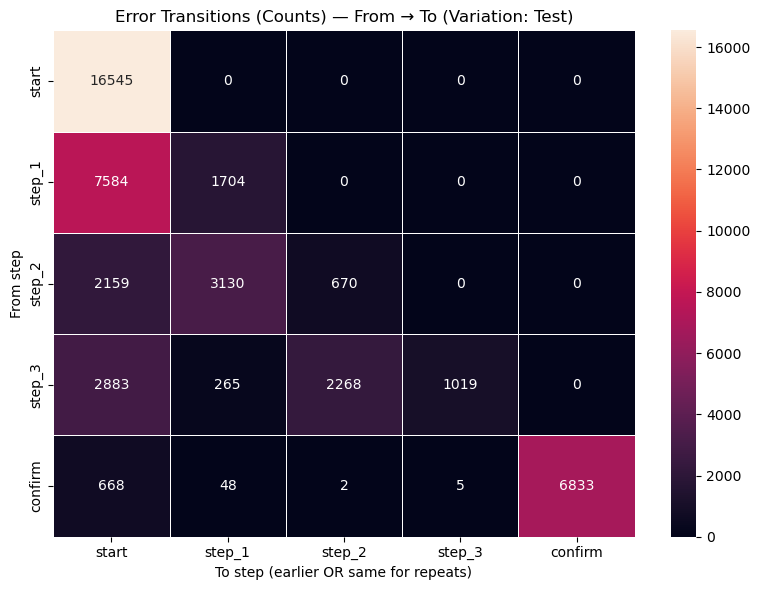

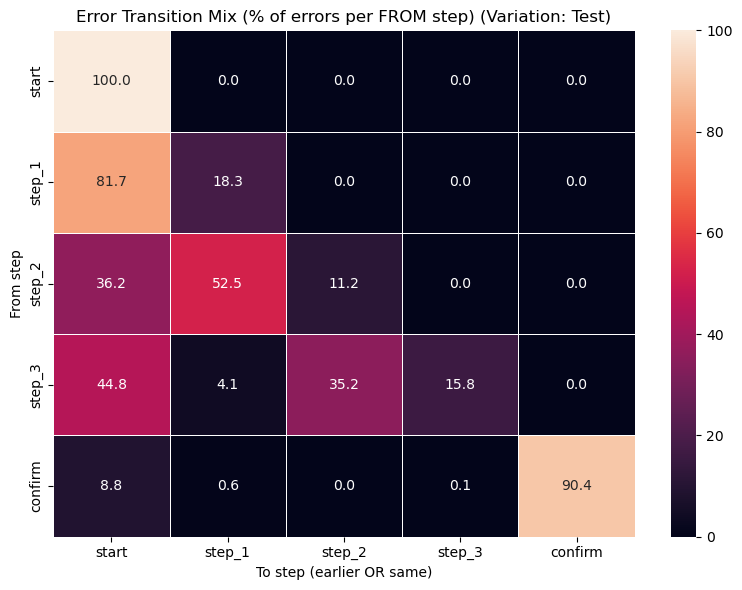

C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\4268691512.py:174: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby('variation')['count']


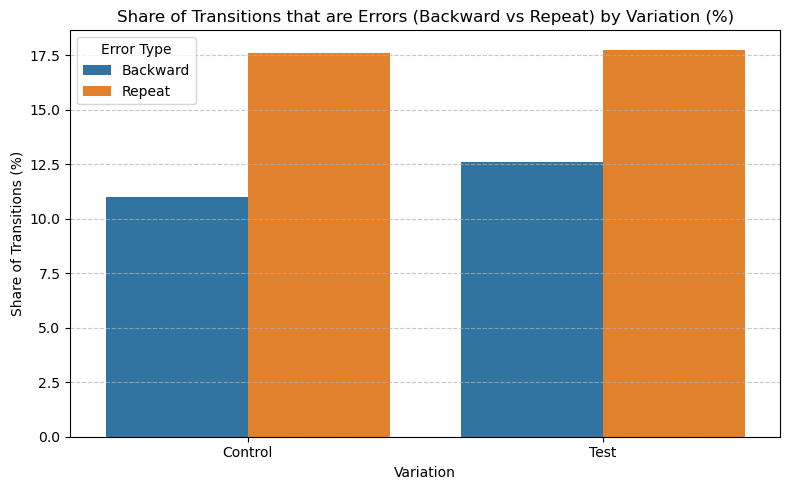

In [57]:
# ---------------------
# CONFIG
# ---------------------
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']  # adjust if needed

# ---------------------
# CLEAN / PREP
# ---------------------
df = df.copy()

# Parse timestamps
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

# Enforce ordered steps
df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)

# Variation as category (deprecation-safe)
if 'variation' in df.columns and not isinstance(df['variation'].dtype, CategoricalDtype):
    df['variation'] = df['variation'].astype('category')
variations = list(df['variation'].cat.categories) if 'variation' in df.columns else []

# Keep rows with valid client & time
df = df[df['client_id'].notna() & df['date_time'].notna()].copy()

# ---------------------
# BUILD TRANSITIONS (include same-step transitions)
# ---------------------
df = df.sort_values(['client_id', 'date_time'])

df['prev_step'] = df.groupby('client_id', observed=True)['process_step'].shift(1)
df['prev_time'] = df.groupby('client_id', observed=True)['date_time'].shift(1)

transitions = df.loc[df['prev_step'].notna(), ['client_id','variation','prev_step','process_step','prev_time','date_time']].copy()
transitions = transitions.rename(columns={'prev_step':'from_step', 'process_step':'to_step'})

# Rank steps
rank = {s:i for i, s in enumerate(step_order)}
transitions['from_rank'] = transitions['from_step'].map(rank)
transitions['to_rank']   = transitions['to_step'].map(rank)

# Classify transitions
transitions['is_repeat']   = transitions['to_rank'] == transitions['from_rank']  # same-step repeat (NEW: count as error)
transitions['is_backward'] = transitions['to_rank'] < transitions['from_rank']   # later -> earlier
transitions['is_forward']  = transitions['to_rank'] > transitions['from_rank']   # normal forward move

# Error definition (NEW): backward OR repeat
transitions['is_error'] = transitions['is_backward'] | transitions['is_repeat']

# Helpful label for type
def _etype(row):
    if row['is_repeat']:   return 'repeat'
    if row['is_backward']: return 'backward'
    return 'forward'
transitions['error_type'] = transitions.apply(_etype, axis=1)

# Transition duration (mins) – not used for flagging, but useful context
transitions['delta_minutes'] = (transitions['date_time'] - transitions['prev_time']).dt.total_seconds() / 60

# ---------------------
# OVERALL & PER-VARIATION KPIs
# ---------------------
def summarize_errors(df_trans):
    total = len(df_trans)
    errs  = int(df_trans['is_error'].sum())
    rate  = (errs / total * 100) if total else 0.0
    # split error types
    counts = df_trans.loc[df_trans['is_error'], 'error_type'].value_counts()
    backward = int(counts.get('backward', 0))
    repeat   = int(counts.get('repeat', 0))
    return pd.Series({
        'total_transitions': total,
        'error_transitions': errs,
        'error_rate_pct': rate,
        'backward_errors': backward,
        'repeat_errors': repeat,
        'backward_share_pct': (backward / errs * 100) if errs else 0.0,
        'repeat_share_pct': (repeat   / errs * 100) if errs else 0.0
    })

summary_overall = summarize_errors(transitions)

if 'variation' in transitions.columns:
    summary_by_var = transitions.groupby('variation', observed=True).apply(summarize_errors).reset_index()
else:
    summary_by_var = pd.DataFrame()

print("=== Error Summary (Overall) ===")
print(summary_overall.to_frame().T.round(2))

if not summary_by_var.empty:
    print("\n=== Error Summary by Variation ===")
    print(summary_by_var.round(2))

# ---------------------
# ERROR RATE BY FROM STEP (per variation)
# ---------------------
def rate_by_from(df_trans):
    g = (df_trans.groupby('from_step', observed=True)['is_error']
                 .agg(total='count', errors='sum')
                 .assign(error_rate_pct=lambda d: np.where(d['total']>0, d['errors']/d['total']*100, 0.0))
                 .reindex(step_order)
                 .fillna({'total':0, 'errors':0, 'error_rate_pct':0.0})
                 .reset_index())
    return g

err_by_from_overall = rate_by_from(transitions)
print("\n=== Error Rate by FROM Step (Overall) ===")
print(err_by_from_overall.round(2))

if 'variation' in transitions.columns:
    print("\n=== Error Rate by FROM Step (by Variation) ===")
    for v in variations:
        tmp = rate_by_from(transitions.loc[transitions['variation']==v])
        print(f"\nVariation = {v}")
        print(tmp.round(2))

# ---------------------
# ERROR TRANSITION MATRICES (errors only), per variation
# ---------------------
errors_only = transitions.loc[transitions['is_error']].copy()

def plot_err_matrix(df_err, title_suffix=""):
    mat = (df_err.groupby(['from_step','to_step'], observed=True)
                 .size()
                 .unstack('to_step')
                 .reindex(index=step_order, columns=step_order)
                 .fillna(0))
    plt.figure(figsize=(8, 6))
    sns.heatmap(mat, annot=True, fmt=".0f", linewidths=.5)
    plt.title(f"Error Transitions (Counts) — From → To {title_suffix}")
    plt.xlabel("To step (earlier OR same for repeats)")
    plt.ylabel("From step")
    plt.tight_layout()
    plt.show()

    # Row-normalized (rates out of errors per FROM step)
    row_totals = mat.sum(axis=1).replace(0, np.nan)
    mat_rates = (mat.div(row_totals, axis=0) * 100).fillna(0)
    plt.figure(figsize=(8, 6))
    sns.heatmap(mat_rates, annot=True, fmt=".1f", linewidths=.5)
    plt.title(f"Error Transition Mix (% of errors per FROM step) {title_suffix}")
    plt.xlabel("To step (earlier OR same)")
    plt.ylabel("From step")
    plt.tight_layout()
    plt.show()

# Overall matrix
if not errors_only.empty:
    plot_err_matrix(errors_only, title_suffix="(Overall)")

# Per-variation matrices
if 'variation' in errors_only.columns:
    for v in variations:
        dfv = errors_only.loc[errors_only['variation']==v]
        if not dfv.empty:
            plot_err_matrix(dfv, title_suffix=f"(Variation: {v})")

# ---------------------
# OPTIONAL: Compact bar comparing overall error rate (backward vs repeat) per variation
# ---------------------
if 'variation' in transitions.columns and not transitions.empty:
    # Label transitions
    plot_df = (
        transitions
        .assign(error_kind=np.where(transitions['is_backward'], 'Backward',
                           np.where(transitions['is_repeat'], 'Repeat', 'Forward')))
        .groupby(['variation', 'error_kind'], observed=True)
        .size()
        .reset_index(name='count')                                 # <- avoid MultiIndex
    )

    # Percent within each variation
    plot_df['percent'] = (
        plot_df.groupby('variation')['count']
               .transform(lambda s: s / s.sum() * 100)
    )

    # Keep only error types
    plot_df = plot_df[plot_df['error_kind'].isin(['Backward', 'Repeat'])]

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, x='variation', y='percent', hue='error_kind')
    plt.title("Share of Transitions that are Errors (Backward vs Repeat) by Variation (%)")
    plt.xlabel("Variation")
    plt.ylabel("Share of Transitions (%)")
    plt.legend(title="Error Type")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\3147297990.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_var = transitions.groupby('variation', observed=True).apply(summarize_errors).reset_index()


=== Error Summary (Overall) ===
   total_transitions  error_transitions  error_rate_pct  backward_errors  \
0           270719.0            32213.0            11.9          32213.0   

   repeat_transitions  backward_share_pct  repeat_share_pct  
0             47861.0                11.9             17.68  

=== Error Summary by Variation ===
  variation  total_transitions  error_transitions  error_rate_pct  \
0   Control           119893.0            13201.0           11.01   
1      Test           150826.0            19012.0           12.61   

   backward_errors  repeat_transitions  backward_share_pct  repeat_share_pct  
0          13201.0             21090.0               11.01             17.59  
1          19012.0             26771.0               12.61             17.75  

=== Error Rate by FROM Step (Overall) ===
  from_step  total  errors  error_rate_pct
0     start  92887       0            0.00
1    step_1  64538   11135           17.25
2    step_2  55552    8036           1

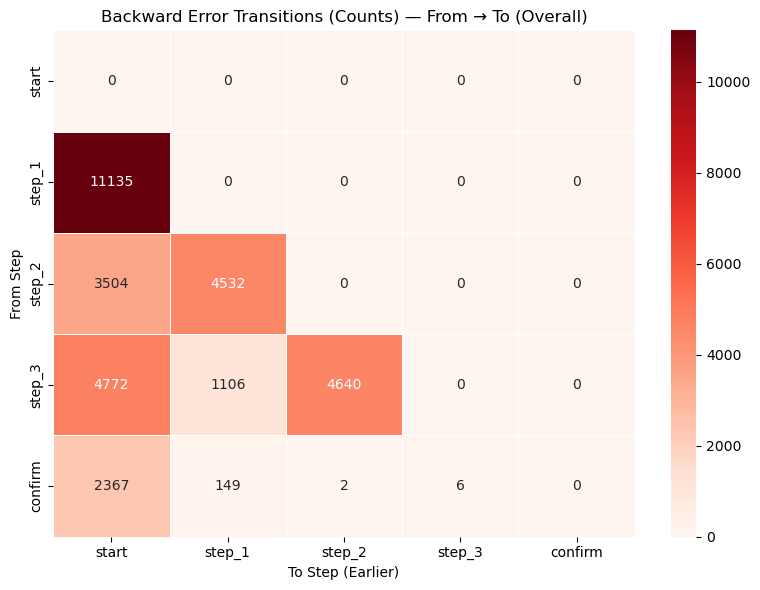

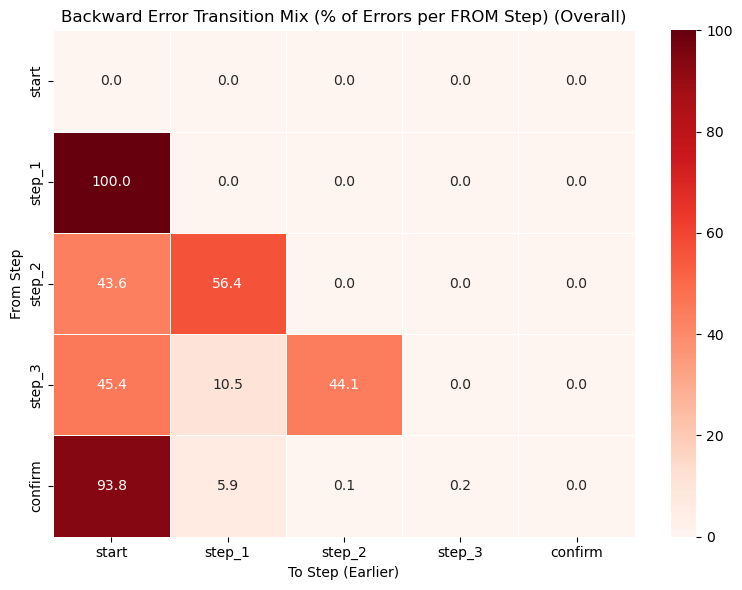

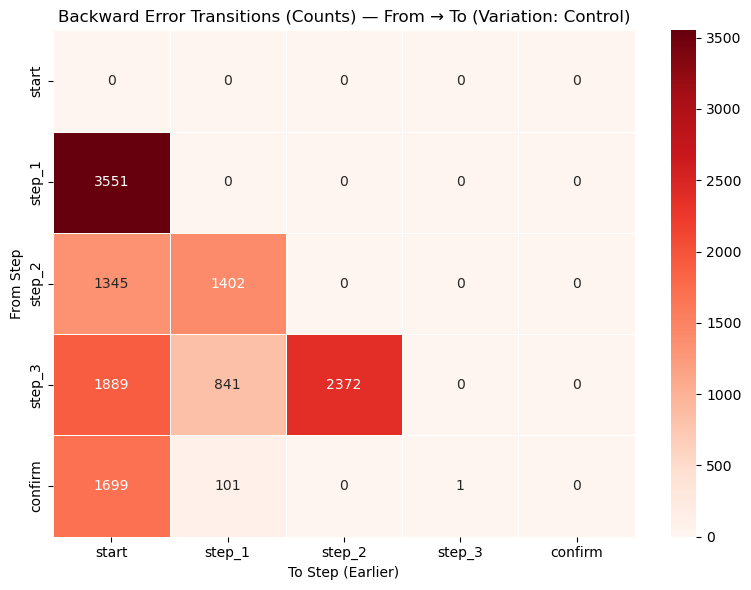

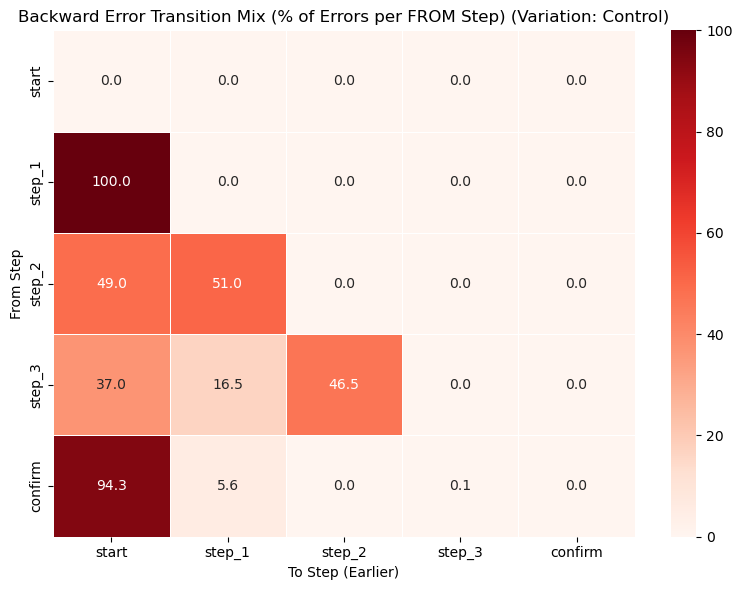

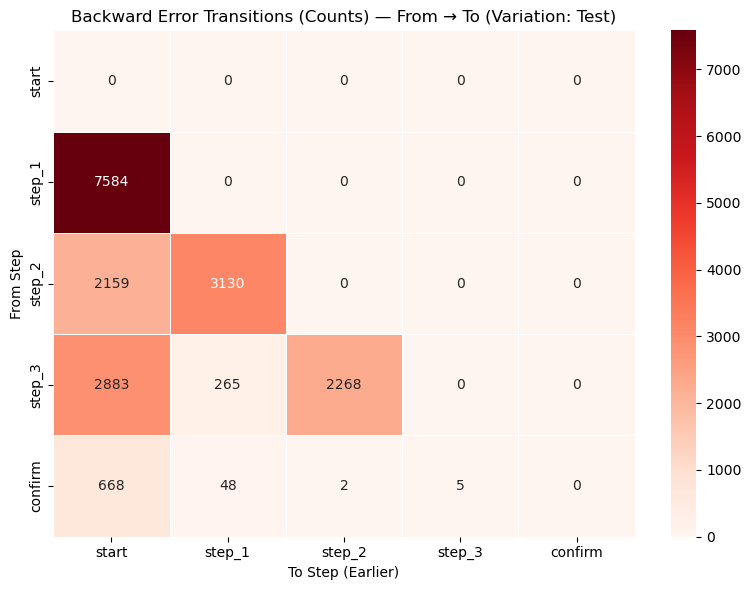

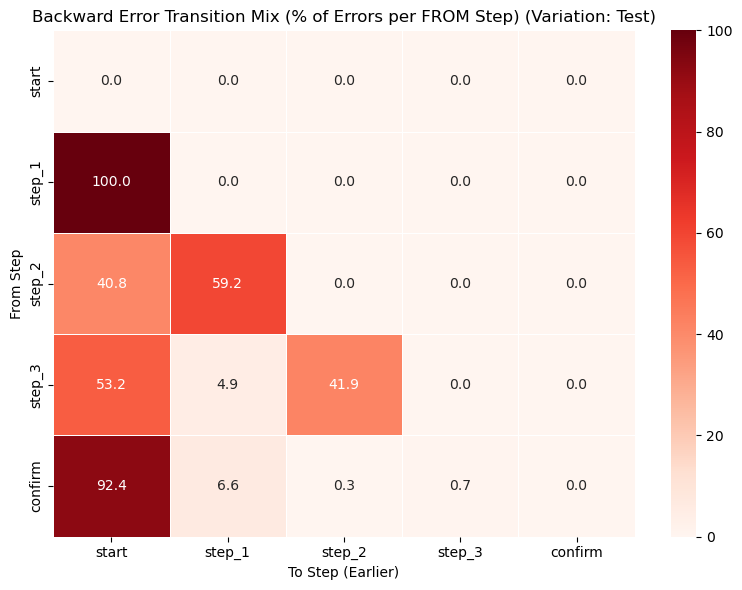

C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\3147297990.py:165: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df['percent'] = plot_df.groupby('variation')['count'].transform(lambda s: s / s.sum() * 100)


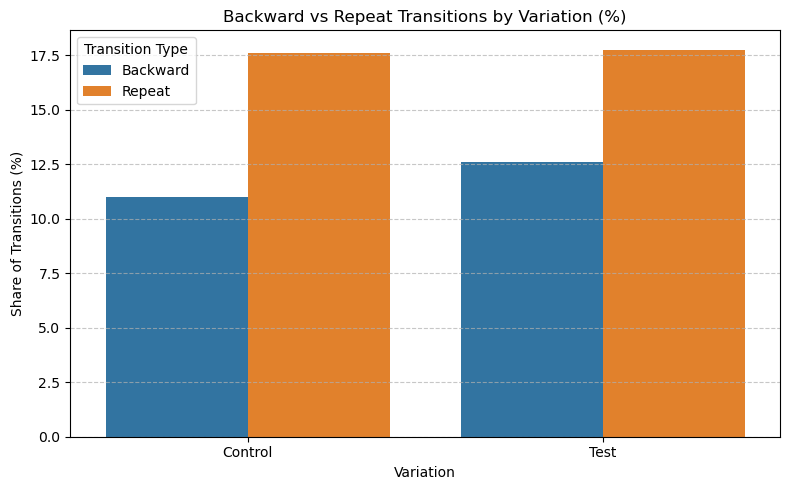

In [58]:
# ---------------------
# CONFIG
# ---------------------
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# ---------------------
# CLEAN / PREP
# ---------------------
df = df.copy()
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

# Enforce ordered steps
df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)

# Ensure variation is categorical
if 'variation' in df.columns and not isinstance(df['variation'].dtype, CategoricalDtype):
    df['variation'] = df['variation'].astype('category')
variations = list(df['variation'].cat.categories) if 'variation' in df.columns else []

# Keep valid rows
df = df[df['client_id'].notna() & df['date_time'].notna()].copy()

# ---------------------
# BUILD TRANSITIONS
# ---------------------
df = df.sort_values(['client_id', 'date_time'])

df['prev_step'] = df.groupby('client_id', observed=True)['process_step'].shift(1)
df['prev_time'] = df.groupby('client_id', observed=True)['date_time'].shift(1)

transitions = df.loc[df['prev_step'].notna(),
                     ['client_id', 'variation', 'prev_step', 'process_step', 'prev_time', 'date_time']].copy()

transitions = transitions.rename(columns={'prev_step':'from_step', 'process_step':'to_step'})

# Rank steps
rank = {s:i for i, s in enumerate(step_order)}
transitions['from_rank'] = transitions['from_step'].map(rank)
transitions['to_rank']   = transitions['to_step'].map(rank)

# Classify transitions
transitions['is_repeat']   = transitions['to_rank'] == transitions['from_rank']
transitions['is_backward'] = transitions['to_rank'] < transitions['from_rank']
transitions['is_forward']  = transitions['to_rank'] > transitions['from_rank']

# ✅ Error = ONLY backward
transitions['is_error'] = transitions['is_backward']

# Label transition type
def _etype(row):
    if row['is_backward']: return 'backward'
    if row['is_repeat']:   return 'repeat'
    return 'forward'
transitions['error_type'] = transitions.apply(_etype, axis=1)

# Time spent per transition
transitions['delta_minutes'] = (transitions['date_time'] - transitions['prev_time']).dt.total_seconds() / 60

# ---------------------
# ERROR SUMMARIES
# ---------------------
def summarize_errors(df_trans):
    total = len(df_trans)
    errs  = int(df_trans['is_error'].sum())
    rate  = (errs / total * 100) if total else 0.0
    backward = errs
    repeat   = int(df_trans['is_repeat'].sum())
    return pd.Series({
        'total_transitions': total,
        'error_transitions': errs,
        'error_rate_pct': rate,
        'backward_errors': backward,
        'repeat_transitions': repeat,
        'backward_share_pct': (backward / total * 100) if total else 0.0,
        'repeat_share_pct': (repeat / total * 100) if total else 0.0
    })

summary_overall = summarize_errors(transitions)

if 'variation' in transitions.columns:
    summary_by_var = transitions.groupby('variation', observed=True).apply(summarize_errors).reset_index()
else:
    summary_by_var = pd.DataFrame()

print("=== Error Summary (Overall) ===")
print(summary_overall.to_frame().T.round(2))

if not summary_by_var.empty:
    print("\n=== Error Summary by Variation ===")
    print(summary_by_var.round(2))

# ---------------------
# ERROR RATE BY FROM STEP
# ---------------------
def rate_by_from(df_trans):
    g = (df_trans.groupby('from_step', observed=True)['is_error']
                 .agg(total='count', errors='sum')
                 .assign(error_rate_pct=lambda d: np.where(d['total']>0, d['errors']/d['total']*100, 0.0))
                 .reindex(step_order)
                 .fillna({'total':0, 'errors':0, 'error_rate_pct':0.0})
                 .reset_index())
    return g

err_by_from_overall = rate_by_from(transitions)
print("\n=== Error Rate by FROM Step (Overall) ===")
print(err_by_from_overall.round(2))

if 'variation' in transitions.columns:
    print("\n=== Error Rate by FROM Step (by Variation) ===")
    for v in variations:
        tmp = rate_by_from(transitions.loc[transitions['variation']==v])
        print(f"\nVariation = {v}")
        print(tmp.round(2))

# ---------------------
# ERROR TRANSITION MATRICES (backward only)
# ---------------------
errors_only = transitions.loc[transitions['is_error']].copy()

def plot_err_matrix(df_err, title_suffix=""):
    mat = (df_err.groupby(['from_step','to_step'], observed=True)
                 .size()
                 .unstack('to_step')
                 .reindex(index=step_order, columns=step_order)
                 .fillna(0))
    plt.figure(figsize=(8, 6))
    sns.heatmap(mat, annot=True, fmt=".0f", linewidths=.5, cmap="Reds")
    plt.title(f"Backward Error Transitions (Counts) — From → To {title_suffix}")
    plt.xlabel("To Step (Earlier)")
    plt.ylabel("From Step")
    plt.tight_layout()
    plt.show()

    row_totals = mat.sum(axis=1).replace(0, np.nan)
    mat_rates = (mat.div(row_totals, axis=0) * 100).fillna(0)
    plt.figure(figsize=(8, 6))
    sns.heatmap(mat_rates, annot=True, fmt=".1f", linewidths=.5, cmap="Reds")
    plt.title(f"Backward Error Transition Mix (% of Errors per FROM Step) {title_suffix}")
    plt.xlabel("To Step (Earlier)")
    plt.ylabel("From Step")
    plt.tight_layout()
    plt.show()

# Overall backward errors
if not errors_only.empty:
    plot_err_matrix(errors_only, title_suffix="(Overall)")

# Per variation backward errors
if 'variation' in errors_only.columns:
    for v in variations:
        dfv = errors_only.loc[errors_only['variation']==v]
        if not dfv.empty:
            plot_err_matrix(dfv, title_suffix=f"(Variation: {v})")

# ---------------------
# BACKWARD vs REPEAT TRANSITIONS (NOT ERRORS)
# ---------------------
if not summary_by_var.empty:
    plot_df = (transitions
               .assign(kind=np.where(transitions['is_backward'], 'Backward',
                            np.where(transitions['is_repeat'], 'Repeat', 'Forward')))
               .groupby(['variation','kind'], observed=True)
               .size()
               .reset_index(name='count'))
    plot_df['percent'] = plot_df.groupby('variation')['count'].transform(lambda s: s / s.sum() * 100)
    plot_df = plot_df[plot_df['kind'].isin(['Backward','Repeat'])]
    plt.figure(figsize=(8,5))
    sns.barplot(data=plot_df, x='variation', y='percent', hue='kind')
    plt.title("Backward vs Repeat Transitions by Variation (%)")
    plt.xlabel("Variation")
    plt.ylabel("Share of Transitions (%)")
    plt.legend(title="Transition Type")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Variations present (rows):
variation
Test       177787
Control    143420 

Using CONTROL = 'Test' | TEST = 'Control'

=== Completion Rates (all variations) ===
variation  total_users  completers     cr
  Control        23527       15429 65.58%
     Test        26961       18682 69.29%

=== Completion Rates (selected arms) ===
variation  total_users  completers     cr
     Test        26961       18682 69.29%
  Control        23527       15429 65.58%

=== Two-Proportion Z-Test (Completion Rate) ===
Test CR = 69.29%  (18682/26961)
Control    CR = 65.58%  (15429/23527)
Z-statistic = 8.8894
P-value     = 0.0000


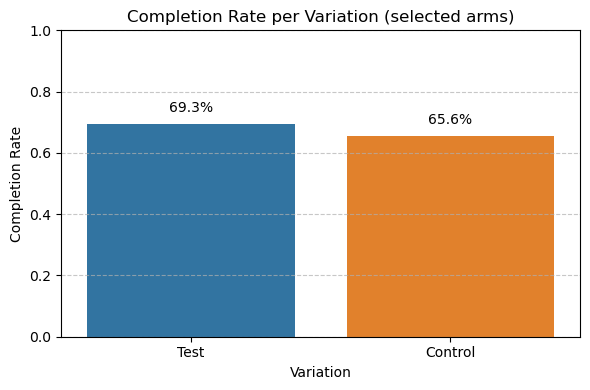


=== Lift Analysis ===
Observed Lift = -5.36%
⚠️ Observed lift below 5% threshold.


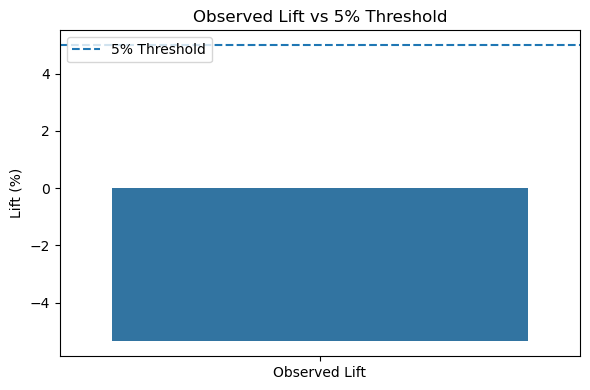


=== Mann–Whitney U Test (Total Time per User) ===
Median Test = 5.47 min  |  n=25605
Median Control    = 5.67 min  |  n=21441
U-statistic = 269424018.0000
P-value     = 0.0005
✅ Significant difference in total time spent.


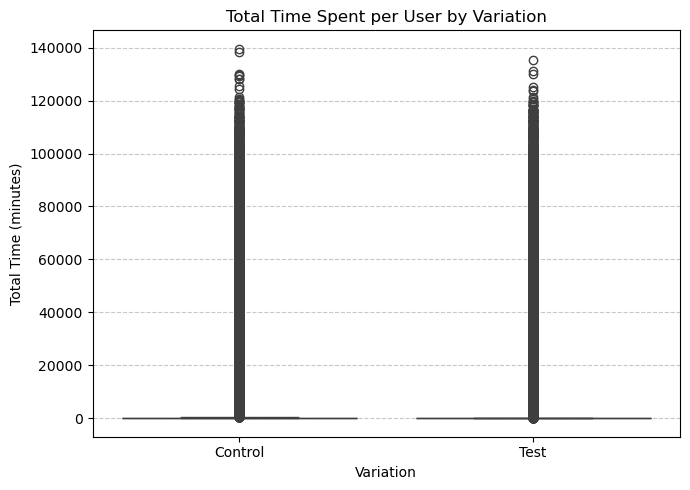


=== Experiment Evaluation ===
📊 Statistically significant but effect size <5% (Test=Control vs Control=Test).

Additional Data Needs:
- Verify sample size & power for a 5% minimum detectable effect (MDE).
- Check pre-experiment balance (traffic mix, devices, geos).
- Consider segment analysis (age, device, channel) for heterogeneous effects.
- Monitor secondary metrics (time to complete, drop-off points, errors).


In [63]:
# =========================
# A/B TEST — ROBUST ANALYSIS (auto-detect variations)
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu
from pandas.api.types import CategoricalDtype

# -------- OPTIONAL: force labels here (set to None to auto-detect) --------
CONTROL_LABEL = None   # e.g., "A" or "control"
TEST_LABEL    = None   # e.g., "B" or "test"

# -------- PREP DATA --------
df = df.copy()

# Make sure variation exists & is categorical
if 'variation' not in df.columns:
    raise ValueError("Column 'variation' is missing in df.")
if not isinstance(df['variation'].dtype, CategoricalDtype):
    df['variation'] = df['variation'].astype('category')

# Show what variations exist
var_counts = df['variation'].value_counts(dropna=False)
print("Variations present (rows):")
print(var_counts.to_string(), "\n")

# Auto-detect control/test if not provided
if CONTROL_LABEL is None or TEST_LABEL is None:
    top_two = var_counts.index.tolist()[:2]
    if len(top_two) < 2:
        raise ValueError("Need at least two variations to compare.")
    CONTROL_LABEL, TEST_LABEL = top_two[0], top_two[1]

print(f"Using CONTROL = '{CONTROL_LABEL}' | TEST = '{TEST_LABEL}'\n")

# -------- 1) COMPLETION RATES + Z-TEST --------
# Unique users reaching confirm per variation
completion_counts = (
    df.loc[df['process_step'] == 'confirm']
      .groupby('variation', observed=True)['client_id']
      .nunique()
)

# Total unique users per variation
total_users = df.groupby('variation', observed=True)['client_id'].nunique()

# Build tidy frame and focus on chosen arms
cr_df_all = (
    pd.DataFrame({
        'variation': total_users.index,
        'total_users': total_users.values,
        'completers': completion_counts.reindex(total_users.index, fill_value=0).values
    })
    .assign(cr=lambda d: d['completers'] / d['total_users'].replace(0, np.nan))
)

# Subset to the two arms
cr_df = cr_df_all.set_index('variation').reindex([CONTROL_LABEL, TEST_LABEL]).reset_index()

print("=== Completion Rates (all variations) ===")
print(cr_df_all[['variation','total_users','completers','cr']].to_string(index=False, formatters={'cr': lambda x: f"{x:.2%}" if pd.notna(x) else "NA"}))
print("\n=== Completion Rates (selected arms) ===")
print(cr_df[['variation','total_users','completers','cr']].to_string(index=False, formatters={'cr': lambda x: f"{x:.2%}" if pd.notna(x) else "NA"}))

p_value = None
lift = None

# Run two-proportion z-test only if both arms have totals > 0
if cr_df['total_users'].min() > 0:
    success = [int(cr_df.loc[cr_df['variation']==CONTROL_LABEL,'completers'].iloc[0]),
               int(cr_df.loc[cr_df['variation']==TEST_LABEL,'completers'].iloc[0])]
    total   = [int(cr_df.loc[cr_df['variation']==CONTROL_LABEL,'total_users'].iloc[0]),
               int(cr_df.loc[cr_df['variation']==TEST_LABEL,'total_users'].iloc[0])]

    stat, p_value = proportions_ztest(success, total)
    cr_control = success[0] / total[0] if total[0] else np.nan
    cr_test    = success[1] / total[1] if total[1] else np.nan
    lift       = ((cr_test - cr_control) / cr_control * 100) if (cr_control is not None and cr_control > 0) else np.nan

    print("\n=== Two-Proportion Z-Test (Completion Rate) ===")
    print(f"{CONTROL_LABEL} CR = {cr_control:.2%}  ({success[0]}/{total[0]})")
    print(f"{TEST_LABEL}    CR = {cr_test:.2%}  ({success[1]}/{total[1]})")
    print(f"Z-statistic = {stat:.4f}")
    print(f"P-value     = {p_value:.4f}")
else:
    print("\n⚠️ One of the arms has zero total users — z-test skipped.")

# Plot completion rates (no palette warning)
plt.figure(figsize=(6,4))
plot_cr = cr_df.assign(cr_plot=lambda d: d['cr'].fillna(0.0))
sns.barplot(data=plot_cr, x='variation', y='cr_plot', hue='variation', legend=False)
plt.title("Completion Rate per Variation (selected arms)")
plt.ylabel("Completion Rate")
plt.xlabel("Variation")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, r in plot_cr.reset_index(drop=True).iterrows():
    label = f"{r['cr_plot']*100:.1f}%"
    plt.text(i, min(r['cr_plot'] + 0.03, 0.98), label, ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# -------- 2) LIFT ≥ 5% CHECK --------
if lift is not None and pd.notna(lift):
    print("\n=== Lift Analysis ===")
    print(f"Observed Lift = {lift:.2f}%")
    if lift >= 5:
        print("✅ Meets or exceeds 5% threshold.")
    else:
        print("⚠️ Observed lift below 5% threshold.")

    plt.figure(figsize=(6,4))
    sns.barplot(x=['Observed Lift'], y=[lift], hue=['Observed Lift'], legend=False)
    plt.axhline(5, linestyle='--', label='5% Threshold')
    plt.ylabel("Lift (%)")
    plt.title("Observed Lift vs 5% Threshold")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Lift not available (control CR is zero or data missing).")

# -------- 3) SECOND TEST: TOTAL TIME SPENT PER USER (Mann–Whitney U) --------
# Build per-user total time across steps using next event timestamp
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')
df = df.sort_values(['client_id', 'date_time'])
df['next_time'] = df.groupby('client_id', observed=True)['date_time'].shift(-1)
df['time_spent'] = (df['next_time'] - df['date_time']).dt.total_seconds() / 60  # minutes

# Sum per user per variation (silence FutureWarning with observed=True)
user_time = (
    df.groupby(['variation','client_id'], observed=True)['time_spent']
      .sum(min_count=1)
      .reset_index()
)

if set([CONTROL_LABEL, TEST_LABEL]).issubset(user_time['variation'].unique()):
    tc = user_time.loc[user_time['variation']==CONTROL_LABEL, 'time_spent'].dropna()
    tt = user_time.loc[user_time['variation']==TEST_LABEL,    'time_spent'].dropna()

    if len(tc) > 0 and len(tt) > 0:
        u_stat, p_value_time = mannwhitneyu(tc, tt, alternative='two-sided')
        print("\n=== Mann–Whitney U Test (Total Time per User) ===")
        print(f"Median {CONTROL_LABEL} = {tc.median():.2f} min  |  n={len(tc)}")
        print(f"Median {TEST_LABEL}    = {tt.median():.2f} min  |  n={len(tt)}")
        print(f"U-statistic = {u_stat:.4f}")
        print(f"P-value     = {p_value_time:.4f}")
        if p_value_time < 0.05:
            print("✅ Significant difference in total time spent.")
        else:
            print("❌ No significant difference in total time spent.")

        plt.figure(figsize=(7,5))
        sns.boxplot(data=user_time[user_time['variation'].isin([CONTROL_LABEL, TEST_LABEL])],
                    x='variation', y='time_spent')
        plt.title("Total Time Spent per User by Variation")
        plt.ylabel("Total Time (minutes)")
        plt.xlabel("Variation")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️ Not enough non-null time data to run Mann–Whitney U test.")
else:
    print("\n⚠️ Missing one of the selected variations in user_time — time test skipped.")

# -------- 4) EXPERIMENT EVALUATION (SAFE) --------
print("\n=== Experiment Evaluation ===")
p_value_eval = locals().get('p_value', None)
lift_eval    = locals().get('lift', None)

if (p_value_eval is not None) and (lift_eval is not None) and pd.notna(lift_eval):
    if p_value_eval < 0.05 and lift_eval >= 5:
        print(f"🎯 The new design ({TEST_LABEL}) is effective vs {CONTROL_LABEL}: significant and ≥5% lift.")
    elif p_value_eval < 0.05 and lift_eval < 5:
        print(f"📊 Statistically significant but effect size <5% (Test={TEST_LABEL} vs Control={CONTROL_LABEL}).")
    else:
        print(f"❌ No significant improvement detected ({TEST_LABEL} vs {CONTROL_LABEL}).")
else:
    print("⚠️ Skipped: need both p-value (z-test) and lift to evaluate conclusively.")

print("\nAdditional Data Needs:")
print("- Verify sample size & power for a 5% minimum detectable effect (MDE).")
print("- Check pre-experiment balance (traffic mix, devices, geos).")
print("- Consider segment analysis (age, device, channel) for heterogeneous effects.")
print("- Monitor secondary metrics (time to complete, drop-off points, errors).")


In [65]:
# ---------------------
# CONFIG
# ---------------------
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# If you want to force specific labels, set these; otherwise leave as None to auto-detect top 2 arms.
FORCE_CONTROL = None   # e.g., "Control"
FORCE_TEST    = None   # e.g., "Test"

# ---------------------
# CLEAN DATA
# ---------------------
df = df.copy()
df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)
if 'variation' not in df.columns:
    raise ValueError("Column 'variation' is missing.")
if not isinstance(df['variation'].dtype, CategoricalDtype):
    df['variation'] = df['variation'].astype('category')

# ---------------------
# USERS PER STEP (TABLE)
# ---------------------
users_per_step = (
    df.groupby(['variation','process_step'], observed=True)['client_id']
      .nunique()
      .reset_index()
      .pivot(index='process_step', columns='variation', values='client_id')
      .reindex(step_order)
      .fillna(0)
      .astype(int)
)

print("=== Users per Step (by Variation) ===")
try:
    display(users_per_step)
except Exception:
    print(users_per_step.to_string())

# ---------------------
# PICK CONTROL & TEST LABELS
# ---------------------
if FORCE_CONTROL is not None and FORCE_TEST is not None:
    control_label, test_label = FORCE_CONTROL, FORCE_TEST
else:
    # pick the two largest variations by total unique users
    totals = df.groupby('variation', observed=True)['client_id'].nunique().sort_values(ascending=False)
    if len(totals) < 2:
        raise ValueError("Need at least two variations to compare.")
    control_label, test_label = totals.index[0], totals.index[1]

print(f"\nUsing CONTROL = '{control_label}' | TEST = '{test_label}'")

# ---------------------
# COMPLETION RATES
# ---------------------
completion_counts = (
    df.loc[df['process_step'] == 'confirm']
      .groupby('variation', observed=True)['client_id']
      .nunique()
)
total_users = df.groupby('variation', observed=True)['client_id'].nunique()

# Build tidy frame for selected arms (use exact labels incl. capitalization)
cr_df = (
    pd.DataFrame({
        'variation': [control_label, test_label],
        'total_users': [total_users.get(control_label, 0), total_users.get(test_label, 0)],
        'completers': [completion_counts.get(control_label, 0), completion_counts.get(test_label, 0)],
    })
    .assign(cr=lambda d: np.where(d['total_users']>0, d['completers']/d['total_users'], np.nan))
)

print("\n=== Completion Rates (selected arms) ===")
fmt_pct = lambda x: f"{x*100:.2f}%" if pd.notna(x) else "NA"
print(cr_df.assign(cr=lambda d: d['cr'].map(fmt_pct)).to_string(index=False))

# ---------------------
# Z-TEST & LIFT
# ---------------------
p_value = None
lift = None

if cr_df['total_users'].min() > 0:
    success = cr_df['completers'].astype(int).tolist()
    total   = cr_df['total_users'].astype(int).tolist()
    stat, p_value = proportions_ztest(success, total)

    cr_control = success[0] / total[0] if total[0] else np.nan
    cr_test    = success[1] / total[1] if total[1] else np.nan
    lift = ((cr_test - cr_control) / cr_control * 100) if (pd.notna(cr_control) and cr_control > 0) else np.nan

    print("\n=== Two-Proportion Z-Test (Completion Rate) ===")
    print(f"{control_label} CR = {cr_control:.2%}  ({success[0]}/{total[0]})")
    print(f"{test_label}    CR = {cr_test:.2%}  ({success[1]}/{total[1]})")
    print(f"Z-statistic = {stat:.4f}")
    print(f"P-value     = {p_value:.4f}")

    print("\n=== Lift vs Control ===")
    if pd.notna(lift):
        print(f"Observed Lift = {lift:.2f}%")
        if lift >= 5:
            print("✅ Meets or exceeds 5% threshold.")
        else:
            print("⚠️ Observed lift below 5% threshold.")
    else:
        print("⚠️ Lift not available (control CR is zero or missing).")
else:
    print("\n⚠️ Cannot run z-test: one of the arms has zero users.")

# ---------------------
# OPTIONAL: pretty summary table
# ---------------------
summary = pd.DataFrame({
    'Metric': [
        'Total Users (Control)', 'Total Users (Test)',
        'Completers (Control)', 'Completers (Test)',
        'Completion Rate (Control)', 'Completion Rate (Test)',
        'Lift vs Control', 'P-value (Z-test)'
    ],
    'Value': [
        int(total_users.get(control_label, 0)),
        int(total_users.get(test_label, 0)),
        int(completion_counts.get(control_label, 0)),
        int(completion_counts.get(test_label, 0)),
        f"{cr_control*100:.2f}%" if 'cr_control' in locals() and pd.notna(cr_control) else "NA",
        f"{cr_test*100:.2f}%"    if 'cr_test' in locals() and pd.notna(cr_test) else "NA",
        f"{lift:.2f}%" if (lift is not None and pd.notna(lift)) else "NA",
        f"{p_value:.4f}" if p_value is not None else "NA"
    ]
})
print("\n=== Summary ===")
try:
    display(summary)
except Exception:
    print(summary.to_string(index=False))

=== Users per Step (by Variation) ===


variation,Control,Test
process_step,,
start,23392,26672
step_1,20147,24260
step_2,18645,22252
step_3,17417,20876
confirm,15429,18682



Using CONTROL = 'Test' | TEST = 'Control'

=== Completion Rates (selected arms) ===
variation  total_users  completers     cr
     Test        26961       18682 69.29%
  Control        23527       15429 65.58%

=== Two-Proportion Z-Test (Completion Rate) ===
Test CR = 69.29%  (18682/26961)
Control    CR = 65.58%  (15429/23527)
Z-statistic = 8.8894
P-value     = 0.0000

=== Lift vs Control ===
Observed Lift = -5.36%
⚠️ Observed lift below 5% threshold.

=== Summary ===


,Metric,Value
0,Total Users (Control),26961
1,Total Users (Test),23527
2,Completers (Control),18682
3,Completers (Test),15429
4,Completion Rate (Control),69.29%
5,Completion Rate (Test),65.58%
6,Lift vs Control,-5.36%
7,P-value (Z-test),0.0000


🔍 Variations found: ['test' 'control']


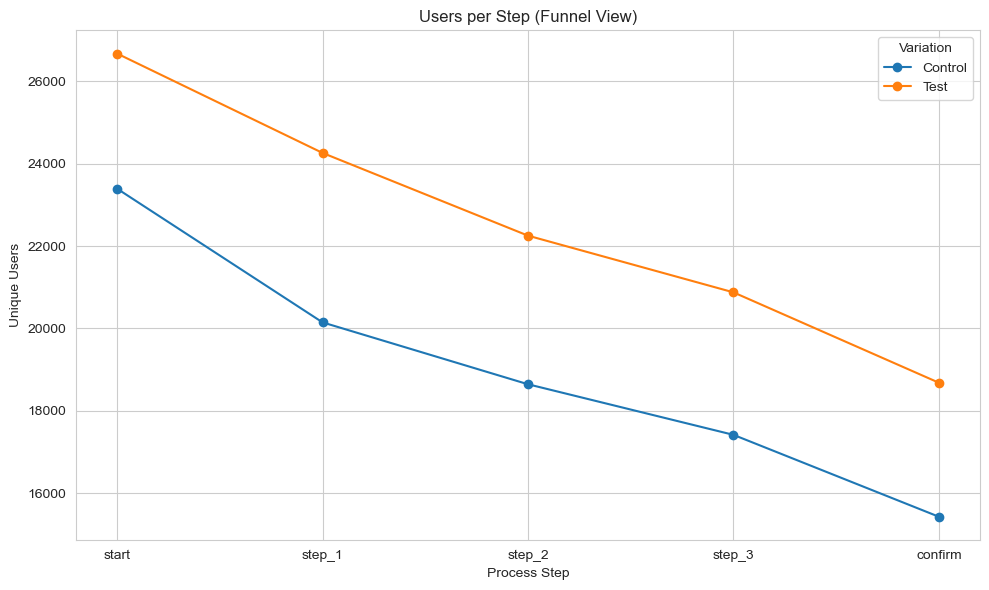


=== Completion Rates (Control vs Test) ===
           Total Users  Completed Users  Completion Rate (%)
variation                                                   
control          23527            15429                65.58
test             26961            18682                69.29

=== Statistical Results ===
Control CR = 65.58%
Test CR    = 69.29%
Observed Lift = 5.66%
Z-statistic  = -8.8894
P-value      = 0.0000
✅ Statistically significant difference!


C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\3993996895.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cr_df, x='Variation', y='Completion Rate (%)', palette=['#4c72b0', '#55a868'])


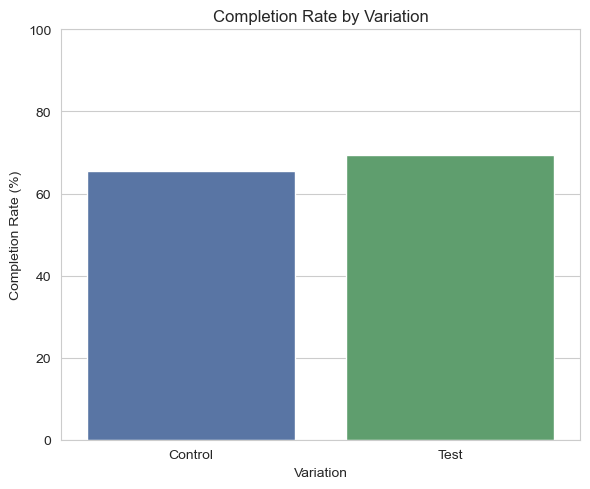

C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\3993996895.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Lift'], y=[lift], palette=['#c44e52' if lift < 0 else '#55a868'])


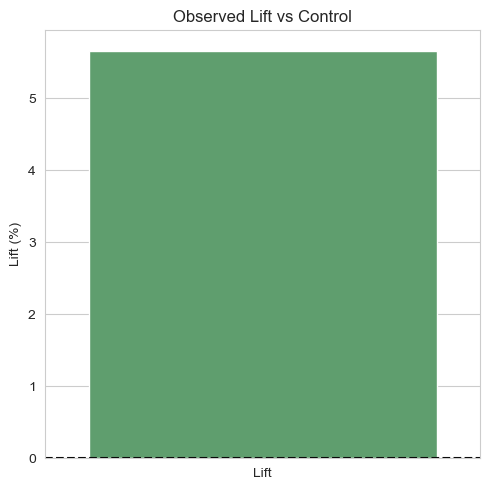

In [67]:
# ---------------------
# CONFIG
# ---------------------
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
sns.set_style("whitegrid")

# ---------------------
# PREP DATA
# ---------------------
df = df.copy()

# Normalize variation labels → lowercase + remove spaces
df['variation'] = df['variation'].str.strip().str.lower()

# Check variations to confirm
print(f"🔍 Variations found: {df['variation'].unique()}")

# Ensure ordered steps
df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)

# Count unique users per step per variation
users_per_step = (
    df.groupby(['variation', 'process_step'], observed=True)['client_id']
      .nunique()
      .unstack('variation')
      .reindex(step_order)
)

# ---------------------
# 1) FUNNEL CHART
# ---------------------
plt.figure(figsize=(10, 6))
for var in users_per_step.columns:
    plt.plot(users_per_step.index, users_per_step[var], marker='o', label=var.capitalize())

plt.title("Users per Step (Funnel View)")
plt.xlabel("Process Step")
plt.ylabel("Unique Users")
plt.legend(title="Variation")
plt.tight_layout()
plt.show()

# ---------------------
# 2) COMPLETION RATE & LIFT
# ---------------------
completion_counts = (
    df[df['process_step'] == 'confirm']
    .groupby('variation', observed=True)['client_id']
    .nunique()
)
total_users = df.groupby('variation', observed=True)['client_id'].nunique()

# Check if both groups exist
if 'control' in completion_counts.index and 'test' in completion_counts.index:
    # Calculate completion rates
    control_cr = completion_counts['control'] / total_users['control']
    test_cr = completion_counts['test'] / total_users['test']
    lift = (test_cr - control_cr) / control_cr * 100

    # Two-proportion Z-test
    stat, p_value = proportions_ztest(
        [completion_counts['control'], completion_counts['test']],
        [total_users['control'], total_users['test']]
    )

    # Summary table
    summary = pd.DataFrame({
        "Total Users": total_users,
        "Completed Users": completion_counts,
        "Completion Rate (%)": (completion_counts / total_users * 100).round(2)
    })
    print("\n=== Completion Rates (Control vs Test) ===")
    print(summary)
    print("\n=== Statistical Results ===")
    print(f"Control CR = {control_cr:.2%}")
    print(f"Test CR    = {test_cr:.2%}")
    print(f"Observed Lift = {lift:.2f}%")
    print(f"Z-statistic  = {stat:.4f}")
    print(f"P-value      = {p_value:.4f}")
    if p_value < 0.05:
        print("✅ Statistically significant difference!")
    else:
        print("❌ No significant difference detected.")
else:
    print("⚠️ Missing 'control' or 'test' variation — please check dataset.")

# ---------------------
# 3) BAR CHART — COMPLETION RATES
# ---------------------
if 'control' in completion_counts.index and 'test' in completion_counts.index:
    cr_df = pd.DataFrame({
        'Variation': ['Control', 'Test'],
        'Completion Rate (%)': [control_cr * 100, test_cr * 100]
    })

    plt.figure(figsize=(6, 5))
    sns.barplot(data=cr_df, x='Variation', y='Completion Rate (%)', palette=['#4c72b0', '#55a868'])
    plt.title("Completion Rate by Variation")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# ---------------------
# 4) BAR CHART — OBSERVED LIFT
# ---------------------
if 'control' in completion_counts.index and 'test' in completion_counts.index:
    plt.figure(figsize=(5, 5))
    sns.barplot(x=['Lift'], y=[lift], palette=['#c44e52' if lift < 0 else '#55a868'])
    plt.title("Observed Lift vs Control")
    plt.ylabel("Lift (%)")
    plt.axhline(0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()

=== Overall Completion Rates ===
Control CR = 65.58%
Test CR    = 69.29%
Lift       = 5.66%
P-value    = 0.0000
✅ Statistically significant difference overall!

=== Completion Rate Analysis by Age Group ===
  Age Group  Control CR  Test CR  Lift (%)  P-value Significant
0       <25       64.27    70.40      9.54     0.00       ✅ Yes
1     25-34       67.05    71.99      7.38     0.00       ✅ Yes
2     35-44       67.47    70.49      4.49     0.00       ✅ Yes
3     45-54       67.04    68.63      2.38     0.09        ❌ No
4     55-64       66.52    69.37      4.28     0.00       ✅ Yes
5       65+       59.02    64.60      9.45     0.00       ✅ Yes


C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\3933885651.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['age_group', 'variation'])['client_id']
C:\Users\jorgi\AppData\Local\Temp\ipykernel_20796\3933885651.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'variation'])['client_id']


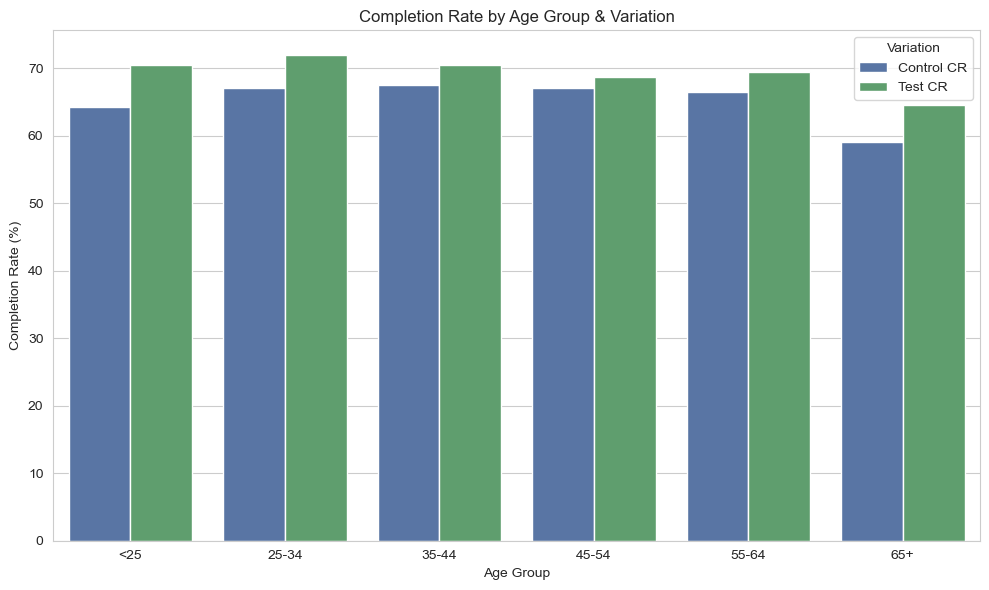

In [68]:
# ---------------------
# CONFIG
# ---------------------
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
age_bins = [0, 24, 34, 44, 54, 64, 120]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
sns.set_style("whitegrid")

# ---------------------
# PREP DATA
# ---------------------
df = df.copy()
df['variation'] = df['variation'].str.strip().str.lower()
df['process_step'] = pd.Categorical(df['process_step'], categories=step_order, ordered=True)
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

# ---------------------
# AGE GROUPS
# ---------------------
df = df[df['clnt_age'].notna()]
df['age_group'] = pd.cut(df['clnt_age'], bins=age_bins, labels=age_labels, include_lowest=True)

# ---------------------
# 1) OVERALL COMPLETION RATES
# ---------------------
completion_counts = df[df['process_step'] == 'confirm'].groupby('variation')['client_id'].nunique()
total_users = df.groupby('variation')['client_id'].nunique()

if 'control' in completion_counts.index and 'test' in completion_counts.index:
    control_cr = completion_counts['control'] / total_users['control']
    test_cr = completion_counts['test'] / total_users['test']
    lift = (test_cr - control_cr) / control_cr * 100

    stat, p_value = proportions_ztest(
        [completion_counts['control'], completion_counts['test']],
        [total_users['control'], total_users['test']]
    )

    print("=== Overall Completion Rates ===")
    print(f"Control CR = {control_cr:.2%}")
    print(f"Test CR    = {test_cr:.2%}")
    print(f"Lift       = {lift:.2f}%")
    print(f"P-value    = {p_value:.4f}")
    if p_value < 0.05:
        print("✅ Statistically significant difference overall!")
    else:
        print("❌ No significant difference overall.")
else:
    print("⚠️ Missing Control or Test variation.")

# ---------------------
# 2) COMPLETION RATES BY AGE GROUP
# ---------------------
age_completion = (
    df[df['process_step'] == 'confirm']
    .groupby(['age_group', 'variation'])['client_id']
    .nunique()
    .unstack('variation')
    .fillna(0)
)

age_totals = (
    df.groupby(['age_group', 'variation'])['client_id']
    .nunique()
    .unstack('variation')
    .fillna(0)
)

age_results = []
for age in age_labels:
    if age not in age_totals.index:
        continue
    if 'control' in age_totals.columns and 'test' in age_totals.columns:
        succ = [age_completion.loc[age, 'control'], age_completion.loc[age, 'test']]
        tot = [age_totals.loc[age, 'control'], age_totals.loc[age, 'test']]

        # Skip empty groups
        if tot[0] == 0 or tot[1] == 0:
            continue

        stat, p_val = proportions_ztest(succ, tot)
        age_results.append({
            'Age Group': age,
            'Control CR': succ[0] / tot[0] * 100,
            'Test CR': succ[1] / tot[1] * 100,
            'Lift (%)': ((succ[1] / tot[1]) - (succ[0] / tot[0])) / (succ[0] / tot[0]) * 100,
            'P-value': p_val,
            'Significant': '✅ Yes' if p_val < 0.05 else '❌ No'
        })

age_summary = pd.DataFrame(age_results)
print("\n=== Completion Rate Analysis by Age Group ===")
print(age_summary.round(2))

# ---------------------
# 3) VISUALIZATION
# ---------------------
if not age_summary.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=age_summary.melt(id_vars=['Age Group', 'P-value', 'Significant'], 
                              value_vars=['Control CR', 'Test CR']),
        x='Age Group', y='value', hue='variable', palette=['#4c72b0', '#55a868']
    )
    plt.title("Completion Rate by Age Group & Variation")
    plt.ylabel("Completion Rate (%)")
    plt.xlabel("Age Group")
    plt.legend(title="Variation")
    plt.tight_layout()
    plt.show()